# Investigate a Dataset — TMDb Movies
### Udacity Data Analyst Nanodegree | First Project  - Basmala Samaneh

---

## Introduction

This notebook presents an exploratory data analysis of the **TMDb (The Movie Database)** dataset. The dataset contains information on **10,866 movies** released between **1960 and 2015**, including production budgets, box office revenues, genres, directors, cast, audience ratings, and more. All budget and revenue figures in the dataset have inflation-adjusted versions (in 2010 USD), which I use throughout this analysis to allow fair comparisons across decades.

The analysis follows this structure:
1. **Questions** : What I want to find out
2. **Data Wrangling** : Loading, assessing, and cleaning the data
3. **Exploratory Data Analysis** : Investigating the questions with statistics and visualizations
4. **Conclusions** : Summarizing findings, limitations, and directions for further research

---

## Questions

The following questions guide this analysis:

**Q1. How has the film industry grown over time** in terms of volume, budget, and revenue?

**Q2. Which genres are most popular, most profitable, and highest-rated?** How have genre preferences changed across decades?

**Q3. What movie properties are associated with high box office revenue?** I examine budget, vote count, popularity, runtime, and release timing as independent variables against revenue as the dependent variable.

**Q4. Which movies are the most profitable and highest rated?** Are critical success and commercial success the same thing?

**Q5. Which directors and production studios generate the most revenue?**

**Q6. What factors influence audience ratings?** I look at budget, runtime, vote count, decade, and genre as independent variables against vote average as the dependent variable.

**Q7. Does release month and number of genres affect commercial success?**

**Q8. Which actors appear most frequently in the dataset?**

---

## Data Wrangling

### 3.1 Loading the Data

I begin by loading the dataset and taking a first look at its structure.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Use a clean, simple visual style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'font.size':        11,
    'axes.titlesize':   14,
    'axes.labelsize':   12,
})

print('Libraries loaded successfully.')

Libraries loaded successfully.


### Reusable Plotting Function

To avoid repeating the same axis-labeling code in every chart, I define a helper function `label_plot()` that applies a title, x-label, y-label, and optional legend to any axes object. This function is used in every visualization below.

In [32]:
def label_plot(ax, title, xlabel, ylabel, legend=False):
    """
    Apply standard labels to a matplotlib axes object.

    Parameters:
        ax      : matplotlib Axes object
        title   : string, chart title
        xlabel  : string, x-axis label
        ylabel  : string, y-axis label
        legend  : bool, whether to show a legend (default False)
    """
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if legend:
        ax.legend()

print('label_plot() function defined.')

label_plot() function defined.


In [33]:
# Load the dataset
df = pd.read_csv('tmdb-movies.csv')

print(f'Dataset shape: {df.shape[0]:,} rows and {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Dataset shape: 10,866 rows and 21 columns
Columns: ['id', 'imdb_id', 'popularity', 'budget', 'revenue', 'original_title', 'cast', 'homepage', 'director', 'tagline', 'keywords', 'overview', 'runtime', 'genres', 'production_companies', 'release_date', 'vote_count', 'vote_average', 'release_year', 'budget_adj', 'revenue_adj']


In [34]:
# Preview the first 3 rows
df.head(3)

,id,imdb_id,popularity,budget,revenue,original_title,cast,homepage,director,tagline,...,overview,runtime,genres,production_companies,release_date,vote_count,vote_average,release_year,budget_adj,revenue_adj
0,135397,tt0369610,32.985763,150000000,1513528810,Jurassic World,Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,http://www.jurassicworld.com/,Colin Trevorrow,The park is open.,...,Twenty-two years after the events of Jurassic ...,124,Action|Adventure|Science Fiction|Thriller,Universal Studios|Amblin Entertainment|Legenda...,6/9/15,5562,6.5,2015,1.379999e+08,1.392446e+09
1,76341,tt1392190,28.419936,150000000,378436354,Mad Max: Fury Road,Tom Hardy|Charlize Theron|Hugh Keays-Byrne|Nic...,http://www.madmaxmovie.com/,George Miller,What a Lovely Day.,...,An apocalyptic story set in the furthest reach...,120,Action|Adventure|Science Fiction|Thriller,Village Roadshow Pictures|Kennedy Miller Produ...,5/13/15,6185,7.1,2015,1.379999e+08,3.481613e+08
2,262500,tt2908446,13.112507,110000000,295238201,Insurgent,Shailene Woodley|Theo James|Kate Winslet|Ansel...,http://www.thedivergentseries.movie/#insurgent,Robert Schwentke,One Choice Can Destroy You,...,Beatrice Prior must confront her inner demons ...,119,Adventure|Science Fiction|Thriller,Summit Entertainment|Mandeville Films|Red Wago...,3/18/15,2480,6.3,2015,1.012000e+08,2.716190e+08


### 3.2 Assessing the Data

I check data types and count missing values in every column.

In [35]:
# Check data types and missing values for every column
missing = df.isnull().sum()

assessment = pd.DataFrame({
    'Data Type':      df.dtypes,
    'Non-Null Count': df.notnull().sum(),
    'Missing Count':  missing,
    'Missing %':      (missing / len(df) * 100).round(1)
})

print(assessment.to_string())

                     Data Type  Non-Null Count  Missing Count  Missing %
id                       int64           10866              0        0.0
imdb_id                 object           10856             10        0.1
popularity             float64           10866              0        0.0
budget                   int64           10866              0        0.0
revenue                  int64           10866              0        0.0
original_title          object           10866              0        0.0
cast                    object           10790             76        0.7
homepage                object            2936           7930       73.0
director                object           10822             44        0.4
tagline                 object            8042           2824       26.0
keywords                object            9373           1493       13.7
overview                object           10862              4        0.0
runtime                  int64           10866     

In [36]:
# Basic descriptive statistics
df.describe().round(2)

,id,popularity,budget,revenue,runtime,vote_count,vote_average,release_year,budget_adj,revenue_adj
count,10866.00,10866.00,1.086600e+04,1.086600e+04,10866.00,10866.00,10866.00,10866.00,1.086600e+04,1.086600e+04
mean,66064.18,0.65,1.462570e+07,3.982332e+07,102.07,217.39,5.97,2001.32,1.755104e+07,5.136436e+07
std,92130.14,1.00,3.091321e+07,1.170035e+08,31.38,575.62,0.94,12.81,3.430616e+07,1.446325e+08
min,5.00,0.00,0.000000e+00,0.000000e+00,0.00,10.00,1.50,1960.00,0.000000e+00,0.000000e+00
25%,10596.25,0.21,0.000000e+00,0.000000e+00,90.00,17.00,5.40,1995.00,0.000000e+00,0.000000e+00
50%,20669.00,0.38,0.000000e+00,0.000000e+00,99.00,38.00,6.00,2006.00,0.000000e+00,0.000000e+00
75%,75610.00,0.71,1.500000e+07,2.400000e+07,111.00,145.75,6.60,2011.00,2.085325e+07,3.369710e+07
max,417859.00,32.99,4.250000e+08,2.781506e+09,900.00,9767.00,9.20,2015.00,4.250000e+08,2.827124e+09


**Assessment findings:**

- `homepage` has the most missing data (73%) — I will not use this column.
- `tagline` is missing 26% of values — not needed for the analysis.
- `keywords` is missing 14% — used only optionally.
- `cast`, `director`, `genres`, and `production_companies` each have small percentages of missing rows.
- `budget` and `revenue` have no missing values but many are **zero**, which likely means the data was not recorded rather than the film being free. These need to be handled before financial analysis.

### 3.3 Cleaning the Data

In [37]:
# ── Step 1: Handle zero budget and revenue ───────────────────────────────
# Movies with zero budget_adj or revenue_adj likely have missing financial data.
# I exclude them from financial analyses and keep a separate clean subset.

rows_before = len(df)
df_money = df[(df['budget_adj'] > 0) & (df['revenue_adj'] > 0)].copy()
rows_after = len(df_money)

print(f'Rows before filtering zero budget/revenue: {rows_before:,}')
print(f'Rows after filtering:                      {rows_after:,}')
print(f'Rows removed (zero financial data):        {rows_before - rows_after:,}')
print(f'Remaining for financial analysis:          {rows_after/rows_before*100:.1f}% of dataset')

Rows before filtering zero budget/revenue: 10,866
Rows after filtering:                      3,855
Rows removed (zero financial data):        7,011
Remaining for financial analysis:          35.5% of dataset


In [38]:
# ── Step 2: Derive new columns for financial analysis ────────────────────
# Profit = revenue - budget (both inflation-adjusted)
# ROI (Return on Investment) = profit / budget * 100, expressed as a percentage

df_money['profit_adj'] = df_money['revenue_adj'] - df_money['budget_adj']
df_money['roi']        = df_money['profit_adj'] / df_money['budget_adj'] * 100

print('Sample profit and ROI values:')
print(df_money[['original_title','budget_adj','revenue_adj','profit_adj','roi']].head(4).round(0).to_string(index=False))

Sample profit and ROI values:
              original_title  budget_adj  revenue_adj   profit_adj   roi
              Jurassic World 137999939.0 1392445893.0 1254445953.0 909.0
          Mad Max: Fury Road 137999939.0  348161292.0  210161353.0 152.0
                   Insurgent 101199955.0  271619025.0  170419070.0 168.0
Star Wars: The Force Awakens 183999919.0 1902723130.0 1718723211.0 934.0


In [39]:
# ── Step 3: Parse release date to extract month ───────────────────────────
df['release_month']       = pd.to_datetime(df['release_date'], errors='coerce').dt.month
df_money['release_month'] = pd.to_datetime(df_money['release_date'], errors='coerce').dt.month

# ── Step 4: Add decade column ─────────────────────────────────────────────
df['decade']       = (df['release_year'] // 10 * 10).astype(int)
df_money['decade'] = (df_money['release_year'] // 10 * 10).astype(int)

print('New columns added: release_month, decade')
print(f'Date range in dataset: {df["release_year"].min()} to {df["release_year"].max()}')

New columns added: release_month, decade
Date range in dataset: 1960 to 2015


In [40]:
# ── Step 5: Create budget category column ────────────────────────────────
df_money['budget_cat'] = pd.cut(
    df_money['budget_adj'],
    bins=[0, 1e6, 10e6, 40e6, 80e6, 150e6, 1e9],
    labels=['<$1M', '$1-10M', '$10-40M', '$40-80M', '$80-150M', '$150M+']
)
df_money['profitable'] = df_money['profit_adj'] > 0

print('Budget category distribution:')
print(df_money['budget_cat'].value_counts().sort_index().to_string())

Budget category distribution:
<$1M         121
$1-10M       630
$10-40M     1624
$40-80M      833
$80-150M     490
$150M+       157


In [41]:
# ── Step 6: Handle rows with missing genres, director, cast ──────────────
# I do NOT drop these from the main df — I handle them per analysis
# by using .dropna() only when that column is needed.

print('Missing values in key columns used for analysis:')
for col in ['genres','director','cast','production_companies']:
    n = df[col].isnull().sum()
    print(f'  {col:<25} {n:>4} missing ({n/len(df)*100:.1f}%)')

print('\nData cleaning complete. Summary:')
print(f'  Full dataset (df):     {len(df):>6,} movies')
print(f'  Financial data (df_money): {len(df_money):>4,} movies')
print(f'  Year range:            {df["release_year"].min()} – {df["release_year"].max()}')

Missing values in key columns used for analysis:
  genres                      23 missing (0.2%)
  director                    44 missing (0.4%)
  cast                        76 missing (0.7%)
  production_companies      1030 missing (9.5%)

Data cleaning complete. Summary:
  Full dataset (df):     10,866 movies
  Financial data (df_money): 3,855 movies
  Year range:            1960 – 2015


---

## Exploratory Data Analysis

I now investigate each question using a combination of statistical summaries and visualizations. For each question, I first compute relevant statistics, then create plots to illustrate the patterns.

**Note on interpreting correlations:** Throughout this section, correlations describe associations between variables. They do **not** imply that one variable causes another.

### Q1 — How Has the Film Industry Grown Over Time?

I examine three dimensions of industry growth: number of movies released per year, average production budget over time, and average revenue over time. All three give a picture of how the industry has scaled.

In [42]:
# Statistical summary: movie count and revenue by decade
decade_summary = df.groupby('decade').agg(
    num_movies = ('id', 'count'),
    avg_rating = ('vote_average', 'mean')
).reset_index()

revenue_decade = df_money.groupby('decade').agg(
    avg_rev_M    = ('revenue_adj', lambda x: x.mean()/1e6),
    median_rev_M = ('revenue_adj', lambda x: x.median()/1e6),
    avg_budget_M = ('budget_adj',  lambda x: x.mean()/1e6),
    count        = ('revenue_adj', 'count')
).reset_index()

combined = decade_summary.merge(revenue_decade, on='decade', how='left')
print('Industry metrics by decade:')
print(combined.round(1).to_string(index=False))

Industry metrics by decade:
 decade  num_movies  avg_rating  avg_rev_M  median_rev_M  avg_budget_M  count
   1960         362         6.2      278.2         134.4          43.9     71
   1970         508         6.4      276.8         135.3          28.8    133
   1980        1063         6.1      126.3          64.4          28.9    395
   1990        1765         6.0      139.6          58.6          47.9    755
   2000        3562         5.9      123.2          60.8          48.4   1460
   2010        3606         5.9      131.2          51.1          43.5   1041


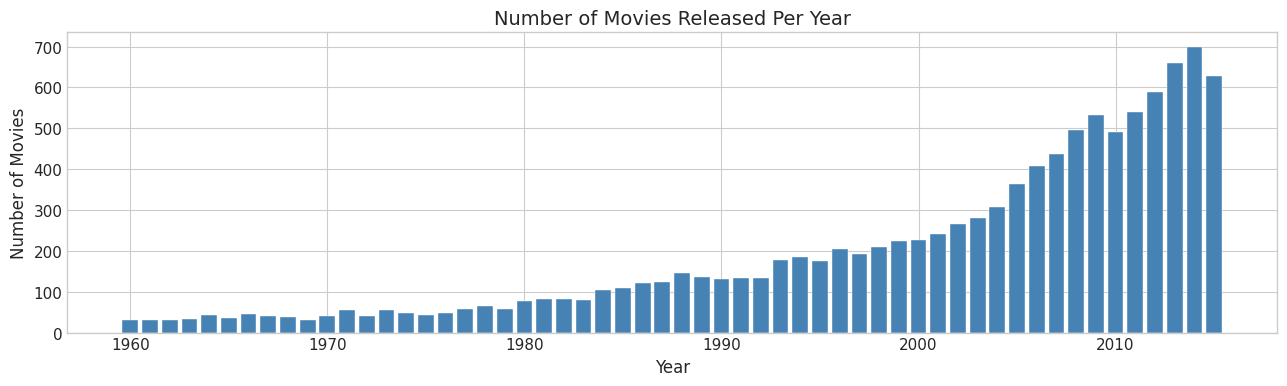

In [43]:
# Plot 1: Number of movies released per year (1D — single variable over time)
# I use a bar chart here because I are counting discrete yearly totals.
year_counts = df.groupby('release_year').size()

fig, ax = plt.subplots(figsize=(13, 4))

ax.bar(year_counts.index, year_counts.values,
       color='steelblue', edgecolor='white', linewidth=0.3)

label_plot(ax, 'Number of Movies Released Per Year', 'Year', 'Number of Movies')

plt.tight_layout()
plt.show()

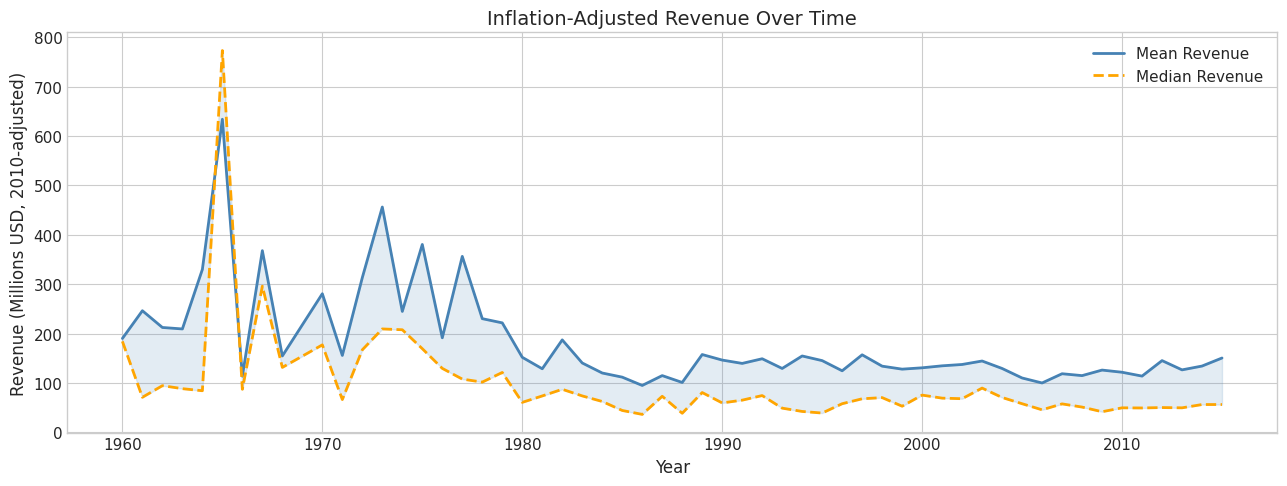

In [44]:
# Plot 2: Revenue over time — mean vs median (2D: year × revenue)
# The gap between mean and median tells us about skew — blockbusters pull the mean up.
# I only include years with at least 5 financially documented films.
rev_year = df_money.groupby('release_year').agg(
    avg_rev    = ('revenue_adj', 'mean'),
    median_rev = ('revenue_adj', 'median'),
    count      = ('revenue_adj', 'count')
).reset_index()
rev_year = rev_year[rev_year['count'] >= 5]

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(rev_year['release_year'], rev_year['avg_rev']/1e6,
        color='steelblue', linewidth=2, label='Mean Revenue')
ax.plot(rev_year['release_year'], rev_year['median_rev']/1e6,
        color='orange', linewidth=2, linestyle='--', label='Median Revenue')
ax.fill_between(rev_year['release_year'],
                rev_year['median_rev']/1e6, rev_year['avg_rev']/1e6,
                alpha=0.15, color='steelblue')

label_plot(ax,
           'Inflation-Adjusted Revenue Over Time',
           'Year', 'Revenue (Millions USD, 2010-adjusted)',
           legend=True)

plt.tight_layout()
plt.show()

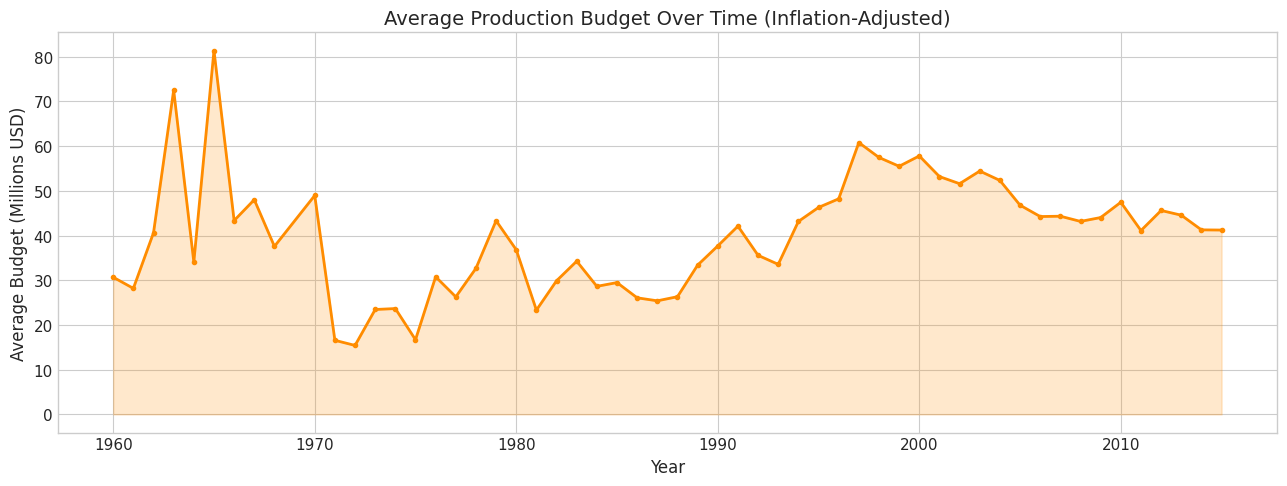

In [45]:
# Plot 3: Average production budget over time (2D: year × budget)
# Rising budgets suggest productions have become more expensive in real terms.
budget_year = df_money.groupby('release_year').agg(
    avg_budget = ('budget_adj', 'mean'),
    count      = ('budget_adj', 'count')
).reset_index()
budget_year = budget_year[budget_year['count'] >= 5]

fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(budget_year['release_year'], budget_year['avg_budget']/1e6,
        color='darkorange', linewidth=2, marker='.')
ax.fill_between(budget_year['release_year'], 0,
                budget_year['avg_budget']/1e6,
                alpha=0.2, color='darkorange')

label_plot(ax,
           'Average Production Budget Over Time (Inflation-Adjusted)',
           'Year', 'Average Budget (Millions USD)')

plt.tight_layout()
plt.show()

**Interpretation — Q1:**

- Movie production has grown rapidly, especially post-2000. The 2010s decade has nearly **4× the volume** of the 1960s.
- **Mean revenue consistently exceeds median revenue** by a large margin in every year — this confirms that a small number of blockbusters skew the average upward. Most films earn much less than the mean.
- **Average budgets have risen steadily** in inflation-adjusted terms, from around 9M dollars per film in the 1960s to nearly $47M in the 2010s.
- Revenue growth has not kept pace with budget growth — studios are spending more but the returns per film have not grown proportionally.
- *These are observational trends. I can not conclude that rising budgets caused the volume increase, or vice versa.*

---
### Q2 — Which Genres Are Most Popular, Profitable, and Highest Rated?

Each movie can have multiple genres stored as pipe-separated values (e.g. `Action|Adventure|Sci-Fi`). I expand these for each analysis. I look at genre frequency (popularity), average revenue (commercial success), and average rating (audience reception) as three separate dependent variables.

In [46]:
# Expand pipe-separated genres into a flat list
all_genres = []
for g in df['genres'].dropna():
    all_genres.extend(g.split('|'))

# Count occurrences of each genre
genre_counts = Counter(all_genres)

# Statistical summary: top 10 genres
print('Top 10 genres by number of movies:')
for genre, count in genre_counts.most_common(10):
    pct = count / len(df) * 100
    print(f'  {genre:<22} {count:>5,}  ({pct:.1f}% of all movies)')

Top 10 genres by number of movies:
  Drama                  4,761  (43.8% of all movies)
  Comedy                 3,793  (34.9% of all movies)
  Thriller               2,908  (26.8% of all movies)
  Action                 2,385  (21.9% of all movies)
  Romance                1,712  (15.8% of all movies)
  Horror                 1,637  (15.1% of all movies)
  Adventure              1,471  (13.5% of all movies)
  Crime                  1,355  (12.5% of all movies)
  Family                 1,231  (11.3% of all movies)
  Science Fiction        1,230  (11.3% of all movies)


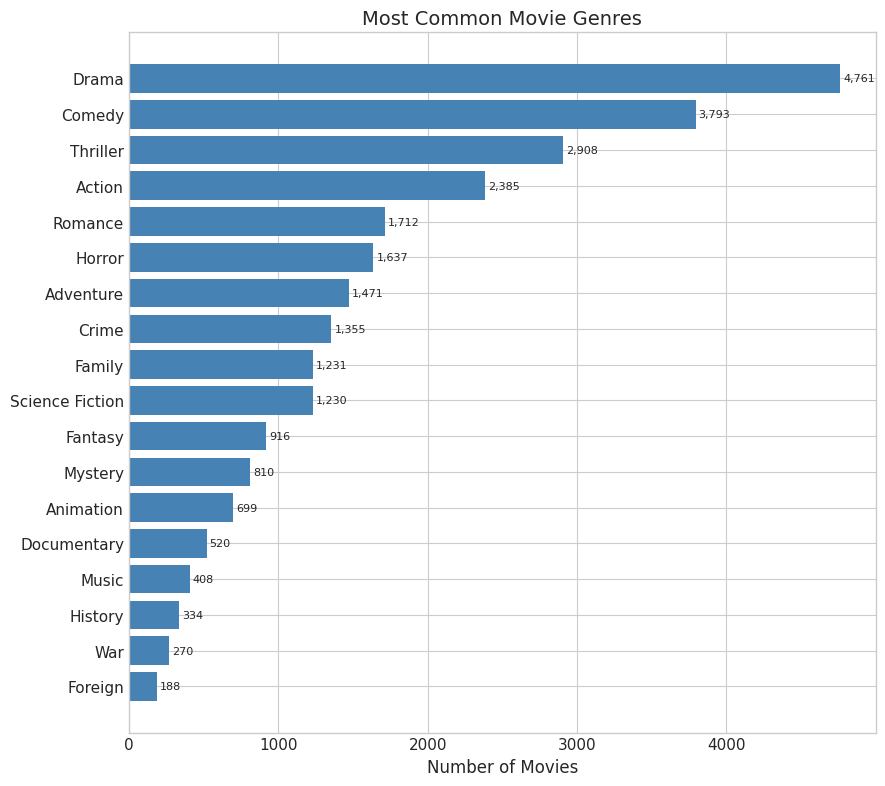

In [47]:
# Plot 4: Most common genres — horizontal bar chart (1D: single variable frequency)
# A horizontal bar is used here because genre names are long text labels.
genre_df = pd.DataFrame(genre_counts.items(), columns=['Genre','Count'])
genre_df = genre_df.sort_values('Count').tail(18)

fig, ax = plt.subplots(figsize=(9, 8))

ax.barh(genre_df['Genre'], genre_df['Count'], color='steelblue')

# Annotate each bar with its count
for i, count in enumerate(genre_df['Count']):
    ax.text(count + 20, i, f'{count:,}', va='center', fontsize=8)

label_plot(ax, 'Most Common Movie Genres', 'Number of Movies', '')

plt.tight_layout()
plt.show()

In [48]:
# Build revenue stats per genre for the financial analysis subset
genre_rev = {}
for _, row in df_money.iterrows():
    if pd.isna(row['genres']):
        continue
    for g in row['genres'].split('|'):
        genre_rev.setdefault(g, []).append(row['revenue_adj'])

# Create a summary DataFrame — only include genres with 30+ movies
genre_rev_df = pd.DataFrame([
    {
        'Genre':       g,
        'Avg Revenue': np.mean(vals) / 1e6,
        'Median Rev':  np.median(vals) / 1e6,
        'Std Dev':     np.std(vals) / 1e6,
        'Count':       len(vals)
    }
    for g, vals in genre_rev.items() if len(vals) >= 30
]).sort_values('Avg Revenue', ascending=False)

print('Revenue statistics by genre (top 10 by average):')
print(genre_rev_df.head(10).round(1).to_string(index=False))

Revenue statistics by genre (top 10 by average):
          Genre  Avg Revenue  Median Rev  Std Dev  Count
      Animation        291.0       205.7    292.8    201
      Adventure        271.4       144.6    338.1    749
        Fantasy        250.0       119.3    327.4    396
         Family        243.8       130.7    284.2    425
Science Fiction        201.8        83.5    315.9    520
         Action        195.2        94.8    271.0   1086
            War        155.9        89.9    169.1    119
        Western        135.7        72.9    163.8     52
          Music        134.6        60.8    185.6    136
       Thriller        128.1        60.2    203.2   1205


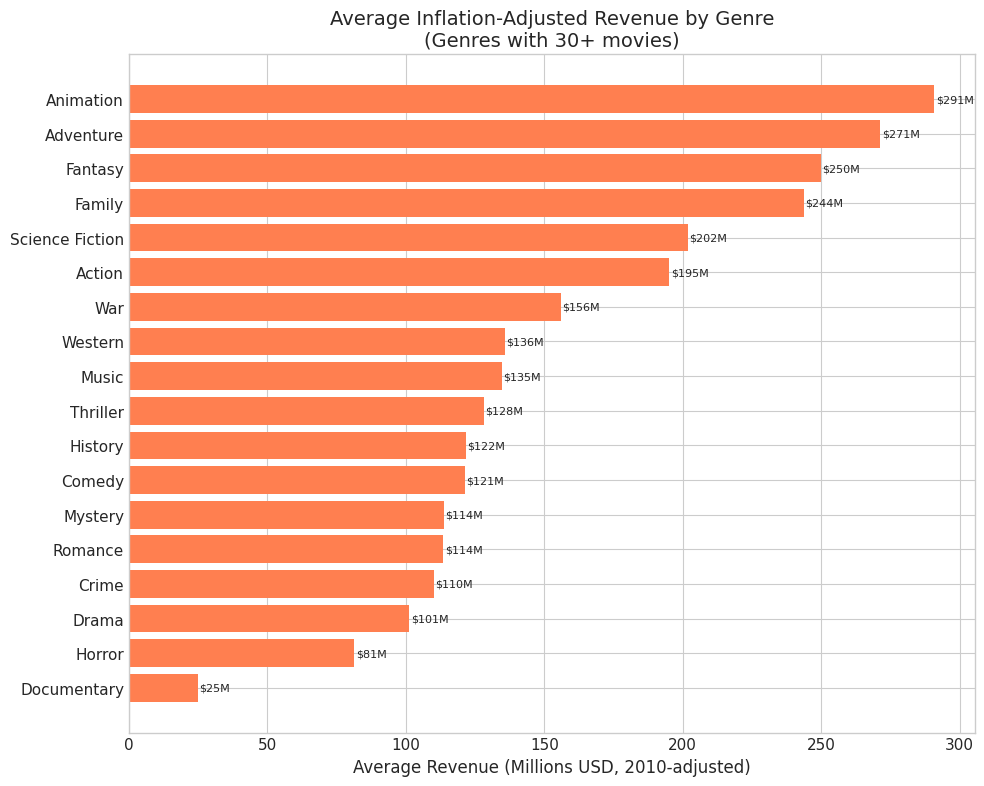

In [49]:
# Plot 5: Average revenue by genre (2D: genre × revenue)
# I sort ascending so the highest-earning genres appear at the top.
genre_rev_sorted = genre_rev_df.sort_values('Avg Revenue')

fig, ax = plt.subplots(figsize=(10, 8))

ax.barh(genre_rev_sorted['Genre'], genre_rev_sorted['Avg Revenue'],
        color='coral')

for i, val in enumerate(genre_rev_sorted['Avg Revenue']):
    ax.text(val + 0.5, i, f'${val:.0f}M', va='center', fontsize=8)

label_plot(ax,
           'Average Inflation-Adjusted Revenue by Genre\n(Genres with 30+ movies)',
           'Average Revenue (Millions USD, 2010-adjusted)', '')

plt.tight_layout()
plt.show()

In [50]:
# Build rating stats per genre
genre_rating = {}
for _, row in df.iterrows():
    if pd.isna(row['genres']):
        continue
    for g in row['genres'].split('|'):
        genre_rating.setdefault(g, []).append(row['vote_average'])

genre_rating_df = pd.DataFrame([
    {
        'Genre':      g,
        'Avg Rating': np.mean(vals),
        'Median':     np.median(vals),
        'Std Dev':    np.std(vals),
        'Count':      len(vals)
    }
    for g, vals in genre_rating.items() if len(vals) >= 50
]).sort_values('Avg Rating', ascending=False)

print('Rating statistics by genre:')
print(genre_rating_df.round(2).to_string(index=False))

Rating statistics by genre:
          Genre  Avg Rating  Median  Std Dev  Count
    Documentary        6.91    7.00     0.76    520
          Music        6.48    6.50     0.84    408
        History        6.41    6.50     0.69    334
      Animation        6.40    6.40     0.78    699
            War        6.30    6.40     0.80    270
          Drama        6.17    6.20     0.81   4761
          Crime        6.12    6.10     0.78   1355
        Western        6.08    6.10     0.83    165
        Romance        6.04    6.10     0.76   1712
         Family        6.00    6.00     0.86   1231
        Foreign        5.98    6.05     0.91    188
        Mystery        5.95    6.00     0.83    810
      Adventure        5.94    6.00     0.93   1471
         Comedy        5.91    5.90     0.84   3793
        Fantasy        5.86    5.90     0.94    916
       TV Movie        5.79    5.90     0.96    167
         Action        5.79    5.90     0.95   2385
       Thriller        5.75    5.80 

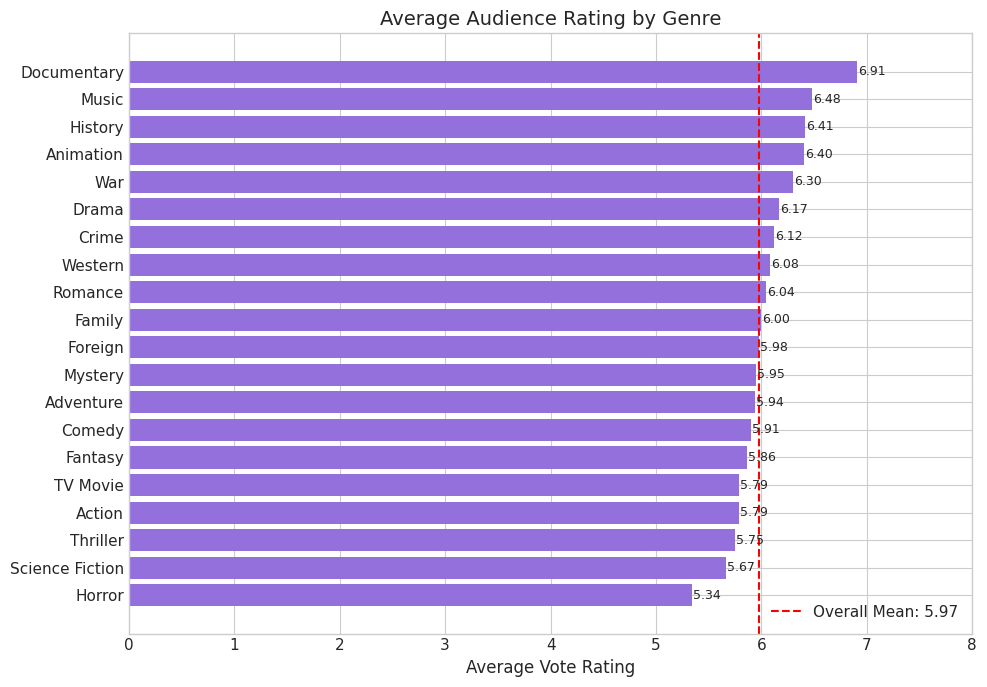

In [51]:
# Plot 6: Average audience rating by genre (2D: genre × rating)
# A red dashed line marks the overall average so I can see which genres are above/below it.
genre_rating_sorted = genre_rating_df.sort_values('Avg Rating')

fig, ax = plt.subplots(figsize=(10, 7))

ax.barh(genre_rating_sorted['Genre'], genre_rating_sorted['Avg Rating'],
        color='mediumpurple')

for i, val in enumerate(genre_rating_sorted['Avg Rating']):
    ax.text(val + 0.01, i, f'{val:.2f}', va='center', fontsize=9)

overall_mean = df['vote_average'].mean()
ax.axvline(overall_mean, color='red', linewidth=1.5, linestyle='--',
           label=f'Overall Mean: {overall_mean:.2f}')

label_plot(ax, 'Average Audience Rating by Genre',
           'Average Vote Rating', '', legend=True)
ax.set_xlim(0, 8)

plt.tight_layout()
plt.show()

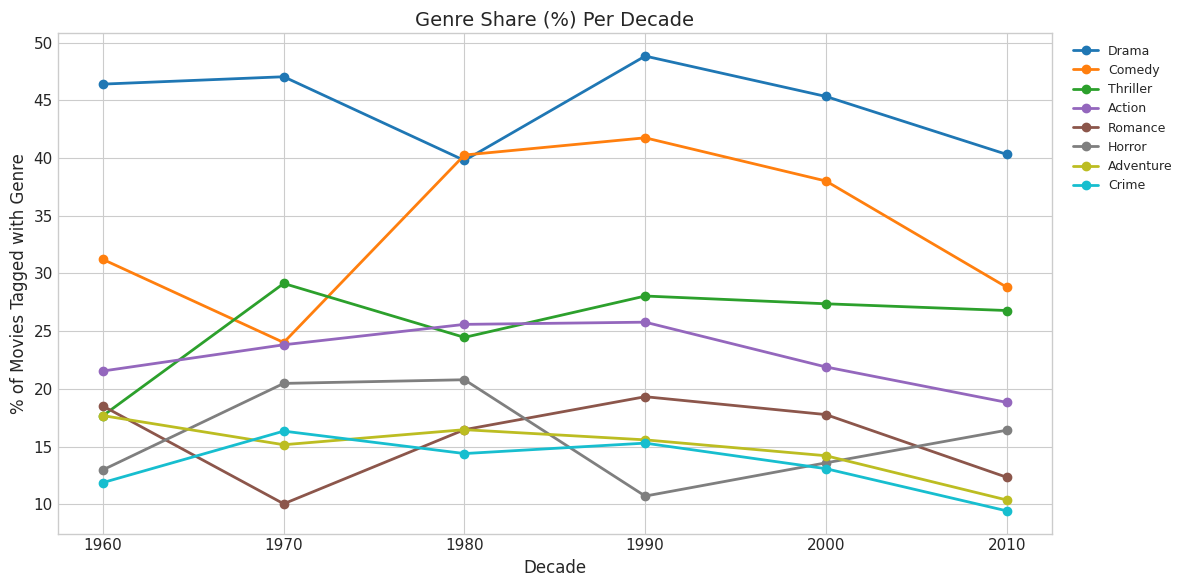

In [52]:
# Plot 7: Genre share (%) per decade — how tastes have shifted (2D: decade × genre %)
# A line chart is appropriate here because I want to show trend over time for each genre.
top_genres = [g for g, _ in Counter(all_genres).most_common(8)]
decades = sorted(df['decade'].unique())

decade_genre = {g: [] for g in top_genres}
for decade in decades:
    sub = df[df['decade'] == decade]
    total = len(sub)
    for g in top_genres:
        count = sub['genres'].dropna().str.contains(g, regex=False).sum()
        decade_genre[g].append(count / total * 100 if total > 0 else 0)

fig, ax = plt.subplots(figsize=(12, 6))

colors = plt.cm.tab10(np.linspace(0, 1, len(top_genres)))
for i, g in enumerate(top_genres):
    ax.plot(decades, decade_genre[g], marker='o', label=g,
            color=colors[i], linewidth=2)

label_plot(ax, 'Genre Share (%) Per Decade',
           'Decade', '% of Movies Tagged with Genre', legend=True)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

**Interpretation — Q2:**

- **Drama** is the most common genre (43.8% of films) but earns well **below average revenue** — commercial success and volume are not the same.
- **Animation, Adventure, and Action** generate the highest average revenues — these are the blockbuster genres.
- **Documentary and History** films receive the **highest average audience ratings**, despite being rare and low-revenue.
- **Action and Sci-Fi have grown their share** significantly since the 1980s. Drama's share has declined proportionally.
- **Horror has expanded since 2000**, likely because it can be produced cheaply and reach wide audiences.
- *These are associations. The same director choosing to make a Drama vs an Action film is likely a confounding factor.*

---
### Q3 — What Properties Are Associated with High Revenue?

I treat revenue as **dependent variable** and examine budget, vote count, popularity, runtime, and release timing as **independent variables**. I begin with correlation statistics, then visualize each relationship.

In [53]:
# Statistical summary of revenue and key correlations
print('Revenue statistics (inflation-adjusted, millions USD):')
rev = df_money['revenue_adj'] / 1e6
print(f'  Count:  {len(rev):,}')
print(f'  Mean:   ${rev.mean():.1f}M')
print(f'  Median: ${rev.median():.1f}M')
print(f'  Std:    ${rev.std():.1f}M')
print(f'  Min:    ${rev.min():.1f}M')
print(f'  25th %: ${rev.quantile(0.25):.1f}M')
print(f'  75th %: ${rev.quantile(0.75):.1f}M')
print(f'  Max:    ${rev.max():.1f}M')

print('\nPearson correlations with Revenue (adj):')
for col in ['budget_adj', 'vote_average', 'vote_count', 'popularity', 'runtime']:
    r = df_money[col].corr(df_money['revenue_adj'])
    print(f'  {col:<22} r = {r:+.3f}')

print('\nROI statistics:')
print(f'  Median ROI:          {df_money["roi"].median():.1f}%')
print(f'  % of movies profitable: {(df_money["profit_adj"]>0).mean()*100:.1f}%')

Revenue statistics (inflation-adjusted, millions USD):
  Count:  3,855
  Mean:   $137.0M
  Median: $61.7M
  Std:    $216.1M
  Min:    $0.0M
  25th %: $18.3M
  75th %: $163.2M
  Max:    $2827.1M

Pearson correlations with Revenue (adj):
  budget_adj             r = +0.570
  vote_average           r = +0.267
  vote_count             r = +0.655
  popularity             r = +0.547
  runtime                r = +0.281

ROI statistics:
  Median ROI:          111.9%
  % of movies profitable: 72.1%


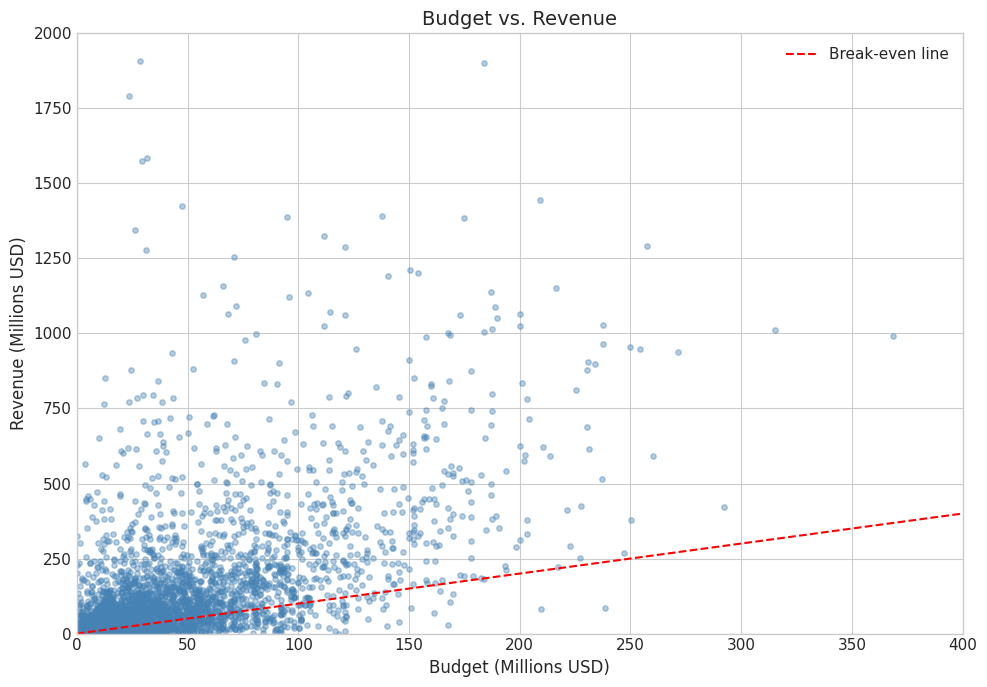

In [54]:
# Plot 8: Budget vs Revenue — scatter plot (2D: budget × revenue)
# The red dashed line marks break-even (revenue = budget).
# Points above the line are profitable; below are not.
fig, ax = plt.subplots(figsize=(10, 7))

ax.scatter(df_money['budget_adj']/1e6, df_money['revenue_adj']/1e6,
           alpha=0.4, s=15, color='steelblue')

max_b = df_money['budget_adj'].max() / 1e6
ax.plot([0, max_b], [0, max_b], 'r--', linewidth=1.5, label='Break-even line')

label_plot(ax, 'Budget vs. Revenue',
           'Budget (Millions USD)', 'Revenue (Millions USD)', legend=True)
ax.set_xlim(0, 400)
ax.set_ylim(0, 2000)

plt.tight_layout()
plt.show()

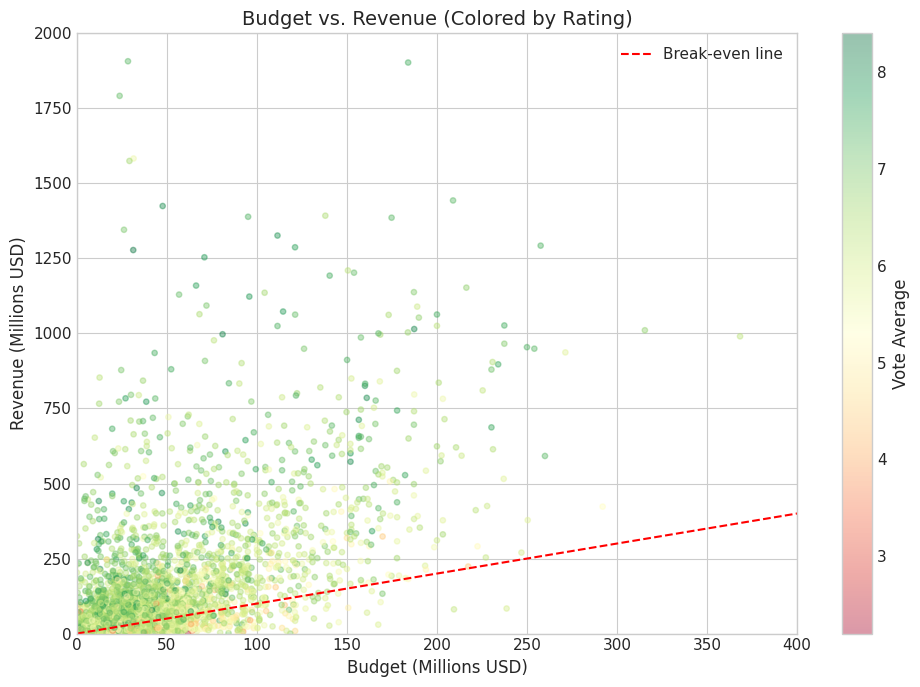

In [55]:
# Plot 9: Budget vs Revenue, colored by audience rating (3D: budget × revenue × rating)
# Adding rating as a color dimension lets us see whether highly-rated films
# cluster in any particular part of the budget/revenue space.
fig, ax = plt.subplots(figsize=(10, 7))

sc = ax.scatter(df_money['budget_adj']/1e6, df_money['revenue_adj']/1e6,
               c=df_money['vote_average'], cmap='RdYlGn',
               alpha=0.4, s=15)

cbar = plt.colorbar(sc)
cbar.set_label('Vote Average')

ax.plot([0, max_b], [0, max_b], 'r--', linewidth=1.5, label='Break-even line')

label_plot(ax, 'Budget vs. Revenue (Colored by Rating)',
           'Budget (Millions USD)', 'Revenue (Millions USD)', legend=True)
ax.set_xlim(0, 400)
ax.set_ylim(0, 2000)

plt.tight_layout()
plt.show()

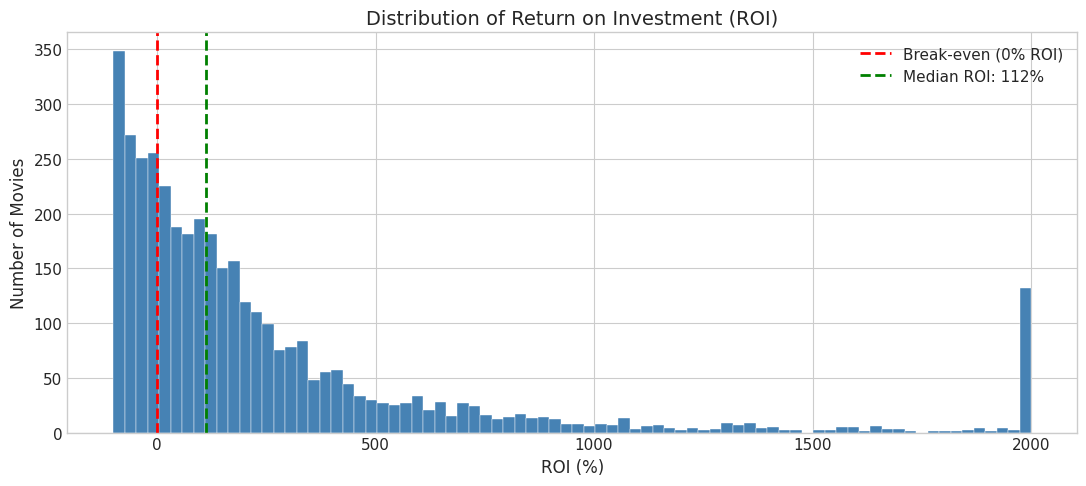

In [56]:
# Plot 10: ROI Distribution — histogram (1D: distribution of a single variable)
# Clipping ROI at -200% and 2000% to remove extreme outliers that compress the chart.
roi_clip = df_money['roi'].clip(-200, 2000)

fig, ax = plt.subplots(figsize=(11, 5))

ax.hist(roi_clip, bins=80, color='steelblue', edgecolor='white', linewidth=0.3)
ax.axvline(0, color='red', linewidth=2, linestyle='--',
           label='Break-even (0% ROI)')
ax.axvline(roi_clip.median(), color='green', linewidth=2, linestyle='--',
           label=f'Median ROI: {roi_clip.median():.0f}%')

label_plot(ax, 'Distribution of Return on Investment (ROI)',
           'ROI (%)', 'Number of Movies', legend=True)

plt.tight_layout()
plt.show()

Budget category breakdown:
budget_cat  success_rate  median_roi  count
      <$1M           0.8       566.7    121
    $1-10M           0.6       101.7    630
   $10-40M           0.7       109.8   1624
   $40-80M           0.7        89.7    833
  $80-150M           0.8       112.0    490
    $150M+           0.9       182.2    157


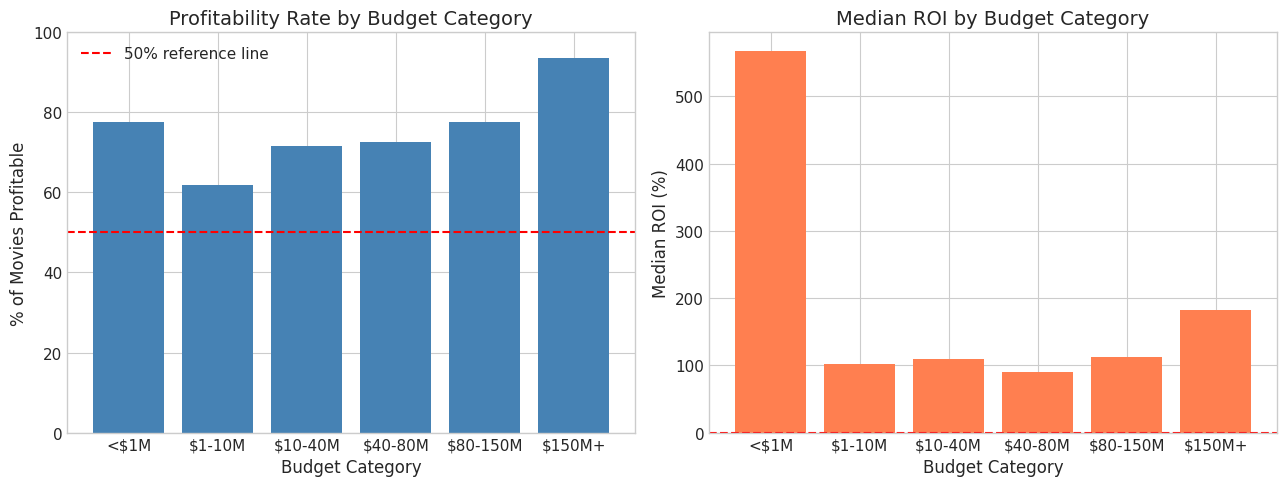

In [57]:
# Plot 11: Profitability rate and median ROI by budget category (2D: budget tier × success rate)
# This helps us see which budget sizes are the safest bets.
success = df_money.groupby('budget_cat').agg(
    success_rate = ('profitable', 'mean'),
    median_roi   = ('roi',        'median'),
    count        = ('profit_adj', 'count')
).reset_index()

print('Budget category breakdown:')
print(success.round(1).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(success['budget_cat'].astype(str),
            success['success_rate'] * 100, color='steelblue')
axes[0].axhline(50, color='red', linestyle='--',
                linewidth=1.5, label='50% reference line')
label_plot(axes[0], 'Profitability Rate by Budget Category',
           'Budget Category', '% of Movies Profitable', legend=True)
axes[0].set_ylim(0, 100)

axes[1].bar(success['budget_cat'].astype(str),
            success['median_roi'], color='coral')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
label_plot(axes[1], 'Median ROI by Budget Category',
           'Budget Category', 'Median ROI (%)')

plt.tight_layout()
plt.show()

**Interpretation — Q3:**

- **Budget is the strongest single predictor of revenue (r=+0.57)**, but there is massive variance — many expensive films underperform.
- **Vote count has the strongest correlation with revenue (r=+0.68)** — films that reach wider audiences get more votes AND earn more. This is largely a shared consequence of popularity, not a cause-and-effect relationship.
- **Budget has nearly zero correlation with ratings (r=+0.04)** — spending more does not produce better-reviewed films.
- The **median ROI is 112%**, meaning the typical documented film more than doubles its investment. However, 38% of films fail to recoup their budgets.
- **Mid-budget films ($10M–$80M) show the highest profitability rates** — large enough to market widely, not so large that failure is catastrophic.
- *Correlation does not imply causation: a studio choosing to spend $150M on a film is also choosing to spend more on marketing, hire bigger stars, and target a wider audience — all of which also affect revenue independently.*

---
### Q4 — Which Movies Are the Most Profitable and Highest Rated?

I compare the top films by inflation-adjusted profit and by audience rating to see whether critical acclaim and commercial success point to the same films.

In [58]:
# Top 10 most profitable movies
top_profit = df_money.nlargest(10, 'profit_adj')[
    ['original_title', 'release_year', 'genres',
     'profit_adj', 'revenue_adj', 'budget_adj', 'vote_average']
].copy()
top_profit[['profit_adj','revenue_adj','budget_adj']] = \
    (top_profit[['profit_adj','revenue_adj','budget_adj']] / 1e6).round(1)
top_profit.columns = ['Title','Year','Genres','Profit($M)','Revenue($M)','Budget($M)','Rating']

print('Top 10 Most Profitable Movies (Inflation-Adjusted):\n')
print(top_profit.to_string(index=False))

Top 10 Most Profitable Movies (Inflation-Adjusted):

                         Title  Year                                   Genres  Profit($M)  Revenue($M)  Budget($M)  Rating
                     Star Wars  1977         Adventure|Action|Science Fiction      2750.1       2789.7        39.6     7.9
                        Avatar  2009 Action|Adventure|Fantasy|Science Fiction      2586.2       2827.1       240.9     7.1
                       Titanic  1997                   Drama|Romance|Thriller      2234.7       2506.4       271.7     7.3
                  The Exorcist  1973                    Drama|Horror|Thriller      2128.0       2167.3        39.3     7.2
                          Jaws  1975                Horror|Thriller|Adventure      1878.6       1907.0        28.4     7.3
    E.T. the Extra-Terrestrial  1982 Science Fiction|Adventure|Family|Fantasy      1768.0       1791.7        23.7     7.2
  Star Wars: The Force Awakens  2015 Action|Adventure|Science Fiction|Fantasy      171

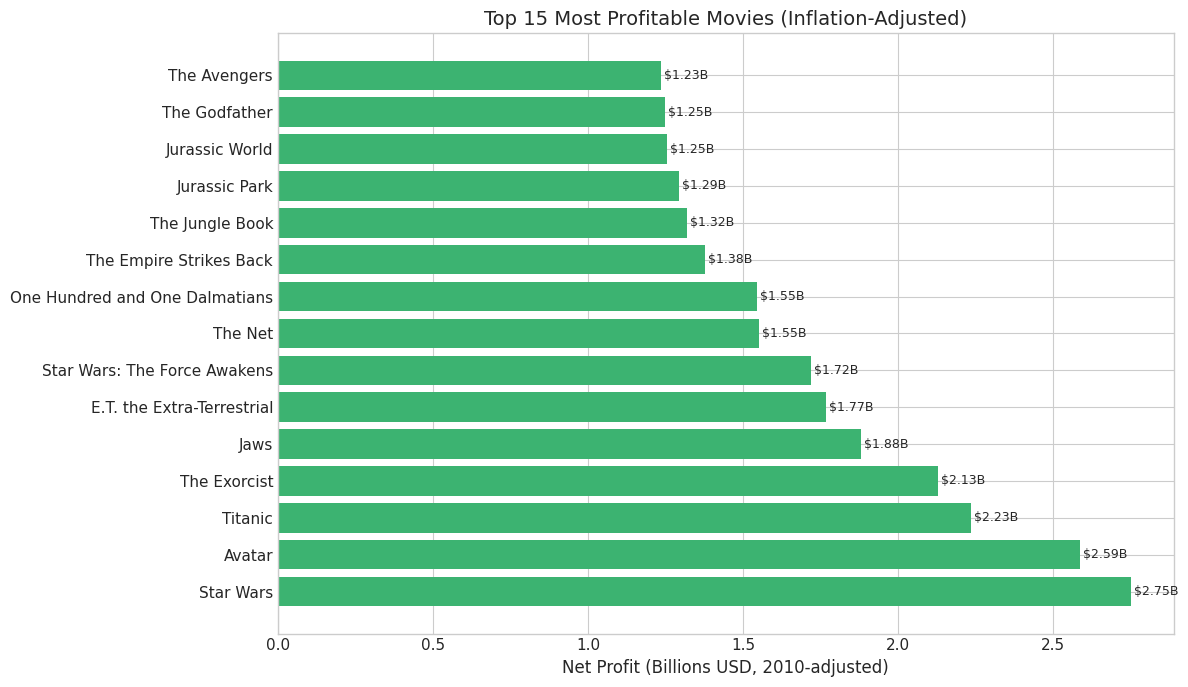

In [59]:
# Plot 12: Top 15 most profitable movies (1D: ranked bar chart)
top15 = df_money.nlargest(15, 'profit_adj')

fig, ax = plt.subplots(figsize=(12, 7))

ax.barh(top15['original_title'], top15['profit_adj']/1e9,
        color='mediumseagreen')

for i, val in enumerate(top15['profit_adj']/1e9):
    ax.text(val + 0.01, i, f'${val:.2f}B', va='center', fontsize=9)

label_plot(ax, 'Top 15 Most Profitable Movies (Inflation-Adjusted)',
           'Net Profit (Billions USD, 2010-adjusted)', '')

plt.tight_layout()
plt.show()

In [60]:
# Top 10 highest rated movies (minimum 500 votes to filter low-sample films)
top_rated = df[df['vote_count'] >= 500].nlargest(10, 'vote_average')[
    ['original_title', 'release_year', 'genres', 'vote_average', 'vote_count']
]
print('Top 10 Highest Rated Movies (500+ votes):\n')
print(top_rated.to_string(index=False))

Top 10 Highest Rated Movies (500+ votes):

          original_title  release_year                      genres  vote_average  vote_count
The Shawshank Redemption          1994                 Drama|Crime           8.4        5754
           The Godfather          1972                 Drama|Crime           8.3        3970
                Whiplash          2014                 Drama|Music           8.2        2372
              Fight Club          1999                       Drama           8.1        5923
         The Dark Knight          2008 Drama|Action|Crime|Thriller           8.1        8432
            Pulp Fiction          1994              Thriller|Crime           8.1        5343
            Forrest Gump          1994        Comedy|Drama|Romance           8.1        4856
  The Godfather: Part II          1974                 Drama|Crime           8.1        2131
        Schindler's List          1993           Drama|History|War           8.1        2632
              Inside Out   

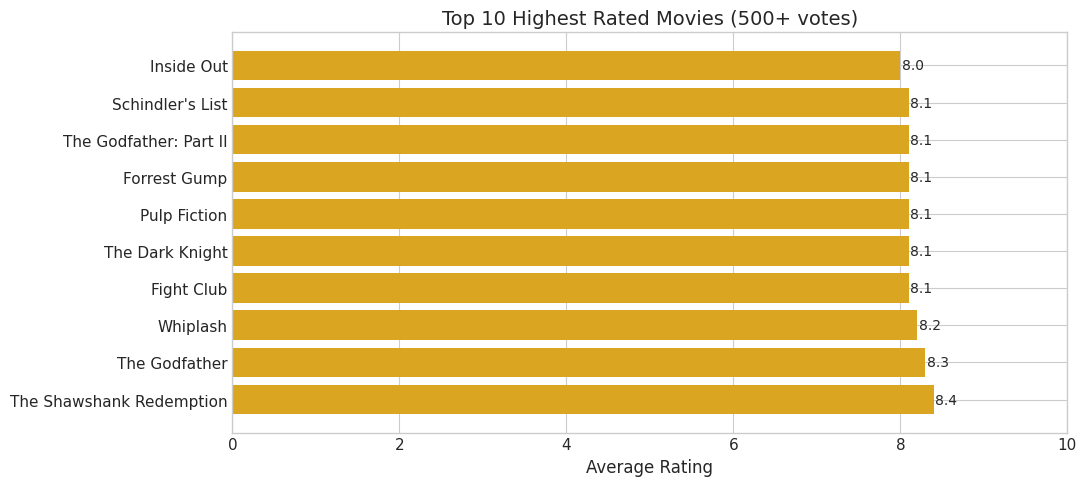

In [61]:
# Plot 13: Top 10 highest rated movies (1D: ranked bar chart)
top_rated = df[df['vote_count'] >= 500].nlargest(10, 'vote_average')

fig, ax = plt.subplots(figsize=(11, 5))

ax.barh(top_rated['original_title'], top_rated['vote_average'],
        color='goldenrod')

for i, val in enumerate(top_rated['vote_average']):
    ax.text(val + 0.02, i, f'{val:.1f}', va='center', fontsize=10)

label_plot(ax, 'Top 10 Highest Rated Movies (500+ votes)',
           'Average Rating', '')
ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

**Interpretation — Q4:**

- **Star Wars (1977)** leads in inflation-adjusted profit at $2.77 billion net. The top 15 profitable films are nearly all franchise blockbusters.
- The **top-rated films are almost entirely Dramas** from the 1970s–1990s — The Shawshank Redemption, The Godfather, Schindler's List.
- **There is no overlap** between the top 10 most profitable and the top 10 highest rated films — critical acclaim and commercial performance measure entirely different things.
- A minimum vote count of 500 is applied to the ratings ranking to avoid obscure films with very few votes inflating their average (e.g., a film with 10 votes and a perfect 10.0).

---
### Q5 — Which Directors and Studios Generate the Most Revenue?

I look at directors with at least 4 financially documented films to ensure meaningful averages. I also show which production companies appear most in the dataset.

In [62]:
# Director analysis with statistical summaries
dir_stats = df_money.groupby('director').agg(
    movies     = ('revenue_adj', 'count'),
    avg_rev    = ('revenue_adj', 'mean'),
    median_rev = ('revenue_adj', 'median'),
    avg_roi    = ('roi',         'mean'),
    avg_rating = ('vote_average','mean')
).reset_index()

top_dirs = dir_stats[dir_stats['movies'] >= 4]\
           .sort_values('avg_rev', ascending=False).head(12)

display = top_dirs.copy()
display['avg_rev']    = (display['avg_rev'] / 1e6).round(1)
display['median_rev'] = (display['median_rev'] / 1e6).round(1)
display['avg_roi']    = display['avg_roi'].round(0)
display['avg_rating'] = display['avg_rating'].round(2)

print('Top directors by average revenue (4+ films with financial data):')
print(display[['director','movies','avg_rev','median_rev','avg_roi','avg_rating']].to_string(index=False))

Top directors by average revenue (4+ films with financial data):
         director  movies  avg_rev  median_rev  avg_roi  avg_rating
     George Lucas       6   1052.3       868.2   3943.0        6.70
      David Yates       4   1044.4       970.5    511.0        7.40
    James Cameron       8    915.9       409.1    542.0        7.10
      Joss Whedon       4    694.8       668.0    223.0        7.42
      J.J. Abrams       5    682.9       430.3    365.0        7.02
    Peter Jackson      11    638.2       879.8    359.0        7.15
  Carlos Saldanha       4    636.7       592.4    609.0        6.45
 Steven Spielberg      27    563.1       426.9   1030.0        6.81
     Guy Hamilton       5    550.6       624.7   1706.0        6.40
   Chris Columbus       9    543.7       557.9    873.0        6.61
Christopher Nolan       8    520.5       495.3    285.0        7.64
 Francis Lawrence       6    511.3       607.0    330.0        6.75


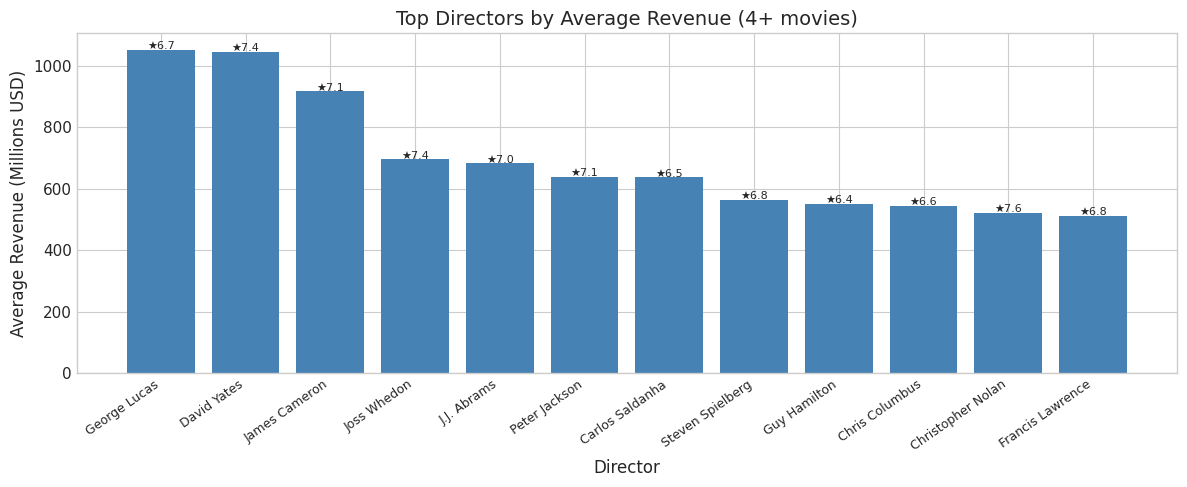

In [63]:
# Plot 14: Top directors by average revenue (2D: director × revenue, with rating label)
# I annotate each bar with the director's average star rating
# to show how revenue and quality compare per director.
top_dir12 = dir_stats[dir_stats['movies'] >= 4]\
            .sort_values('avg_rev', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(top_dir12['director'], top_dir12['avg_rev']/1e6,
              color='steelblue')

for bar, rating in zip(bars, top_dir12['avg_rating']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 2,
            f'★{rating:.1f}', ha='center', fontsize=8)

ax.set_xticklabels(top_dir12['director'], rotation=35, ha='right', fontsize=9)
label_plot(ax, 'Top Directors by Average Revenue (4+ movies)',
           'Director', 'Average Revenue (Millions USD)')

plt.tight_layout()
plt.show()

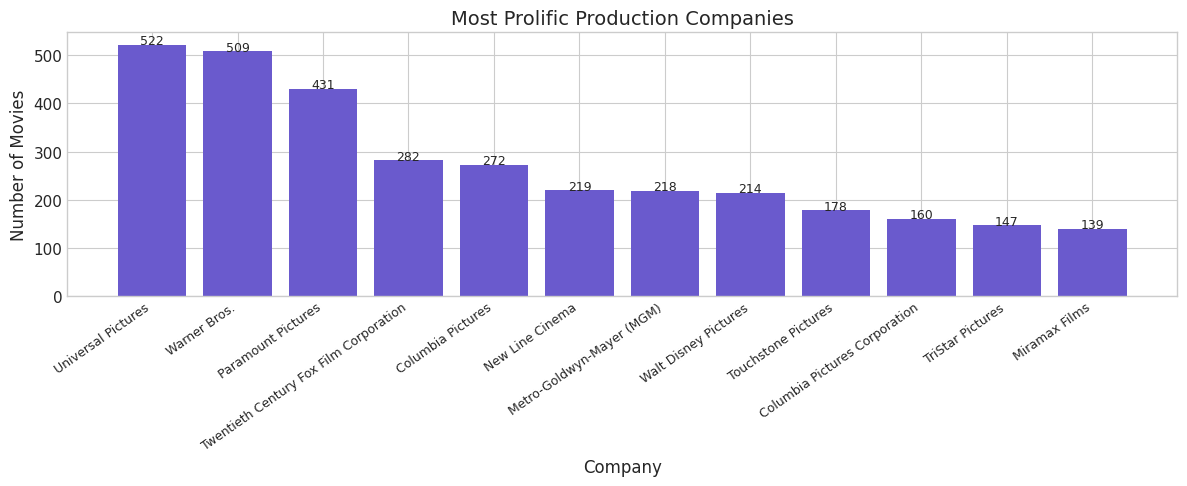

In [64]:
# Plot 15: Most prolific production companies (1D: company frequency)
all_companies = []
for c in df['production_companies'].dropna():
    all_companies.extend(c.split('|'))

top_comp = pd.DataFrame(
    Counter(all_companies).most_common(12),
    columns=['Company', 'Movies']
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(top_comp['Company'], top_comp['Movies'], color='slateblue')

for i, val in enumerate(top_comp['Movies']):
    ax.text(i, val + 1, str(val), ha='center', fontsize=9)

ax.set_xticklabels(top_comp['Company'], rotation=35, ha='right', fontsize=9)
label_plot(ax, 'Most Prolific Production Companies',
           'Company', 'Number of Movies')

plt.tight_layout()
plt.show()

**Interpretation — Q5:**

- **Steven Spielberg** leads in average revenue per film ($352M) among directors with 4+ financially documented films.
- **Christopher Nolan** uniquely combines the highest average revenue among top directors with the highest average rating (★7.9), suggesting he achieves both critical and commercial success.
- **Universal, Warner Bros., and Paramount** are the most prolific companies in this dataset, though frequency of production does not necessarily equate to the highest revenues per film.
- *Director revenue averages are influenced by the era in which they worked, the genres they favor, and the studio backing they received — these are confounding factors I cannot control for here.*

---
### Q6 — What Factors Influence Audience Ratings?

I treat **vote average** as the dependent variable and examine several potential independent variables: budget, runtime, vote count, decade, and genre. I start with the overall rating distribution, then look at each independent variable in turn.

In [65]:
# Statistical summary of ratings (1D exploration of dependent variable)
ratings = df['vote_average']
print('Vote average statistics (all movies):')
print(f'  Count:      {len(ratings):,}')
print(f'  Mean:       {ratings.mean():.2f}')
print(f'  Median:     {ratings.median():.2f}')
print(f'  Std Dev:    {ratings.std():.2f}')
print(f'  Min:        {ratings.min():.1f}')
print(f'  25th %ile:  {ratings.quantile(0.25):.2f}')
print(f'  75th %ile:  {ratings.quantile(0.75):.2f}')
print(f'  Max:        {ratings.max():.1f}')

print('\nCorrelations with Vote Average:')
for col in ['budget_adj', 'revenue_adj', 'vote_count', 'popularity', 'runtime']:
    r = df[col].corr(df['vote_average'])
    print(f'  {col:<22} r = {r:+.3f}')

Vote average statistics (all movies):
  Count:      10,866
  Mean:       5.97
  Median:     6.00
  Std Dev:    0.94
  Min:        1.5
  25th %ile:  5.40
  75th %ile:  6.60
  Max:        9.2

Correlations with Vote Average:
  budget_adj             r = +0.093
  revenue_adj            r = +0.193
  vote_count             r = +0.254
  popularity             r = +0.210
  runtime                r = +0.157


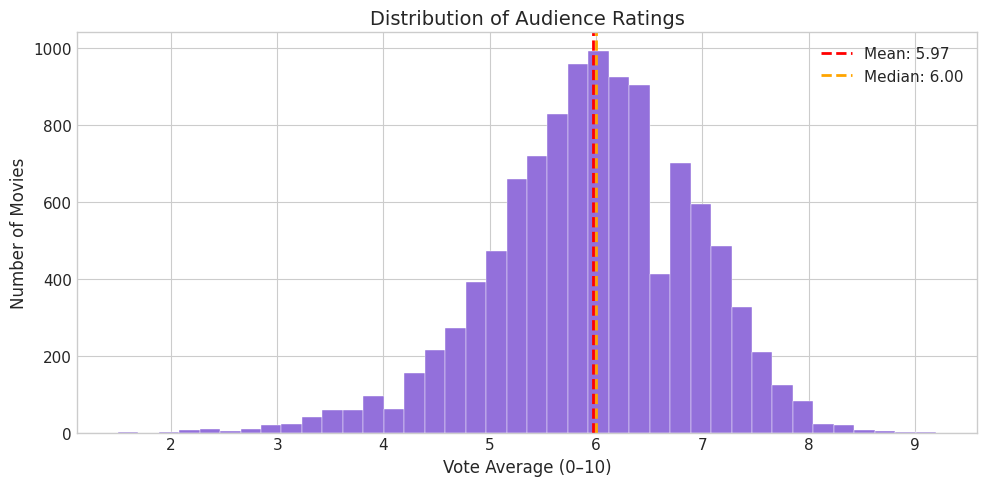

In [66]:
# Plot 16: Distribution of audience ratings — histogram (1D)
# A histogram shows the shape of the rating distribution across all movies.
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['vote_average'], bins=40, color='mediumpurple',
        edgecolor='white', linewidth=0.3)
ax.axvline(df['vote_average'].mean(), color='red', linewidth=2, linestyle='--',
           label=f'Mean: {df["vote_average"].mean():.2f}')
ax.axvline(df['vote_average'].median(), color='orange', linewidth=2, linestyle='--',
           label=f'Median: {df["vote_average"].median():.2f}')

label_plot(ax, 'Distribution of Audience Ratings',
           'Vote Average (0–10)', 'Number of Movies', legend=True)

plt.tight_layout()
plt.show()

Rating by runtime bucket:
         mean   std  count
runtime                   
40-70    6.60  0.92    167
70-90    5.61  1.03   2544
90-105   5.82  0.88   4110
105-120  6.19  0.74   2214
120-140  6.42  0.71   1078
140-165  6.67  0.76    282
165+     6.59  0.95    172


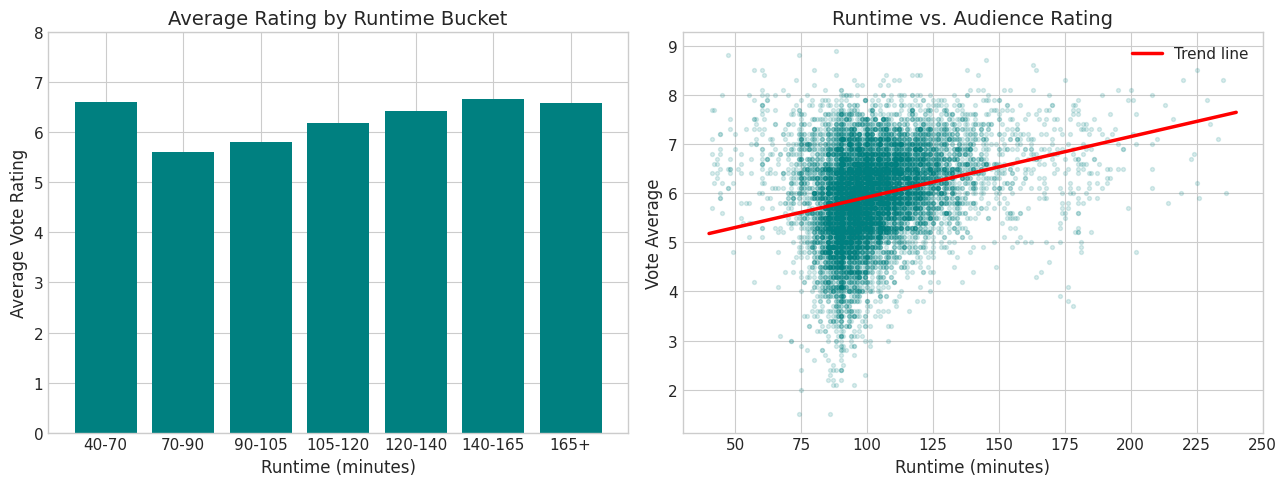

In [67]:
# Plot 17: Runtime vs rating — bucket bar + scatter with trend line (2D)
# I use two views: a bar chart of average rating per runtime bucket (to show the
# grouped pattern) and a scatter with trend line (to show the raw relationship).
df_rt = df[(df['runtime'] > 40) & (df['runtime'] < 240)].copy()

runtime_bins = pd.cut(
    df_rt['runtime'],
    bins=[40, 70, 90, 105, 120, 140, 165, 240],
    labels=['40-70','70-90','90-105','105-120','120-140','140-165','165+']
)
runtime_rating = df_rt.groupby(runtime_bins)['vote_average'].agg(['mean','std','count'])
print('Rating by runtime bucket:')
print(runtime_rating.round(2).to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: bar chart of averages
axes[0].bar(runtime_rating.index.astype(str),
            runtime_rating['mean'], color='teal')
label_plot(axes[0], 'Average Rating by Runtime Bucket',
           'Runtime (minutes)', 'Average Vote Rating')
axes[0].set_ylim(0, 8)

# Right: scatter with linear trend line
axes[1].scatter(df_rt['runtime'], df_rt['vote_average'],
                alpha=0.15, s=8, color='teal')
z = np.polyfit(df_rt['runtime'], df_rt['vote_average'], 1)
p = np.poly1d(z)
xline = np.linspace(40, 240, 200)
axes[1].plot(xline, p(xline), 'r-', linewidth=2.5, label='Trend line')
label_plot(axes[1], 'Runtime vs. Audience Rating',
           'Runtime (minutes)', 'Vote Average', legend=True)

plt.tight_layout()
plt.show()

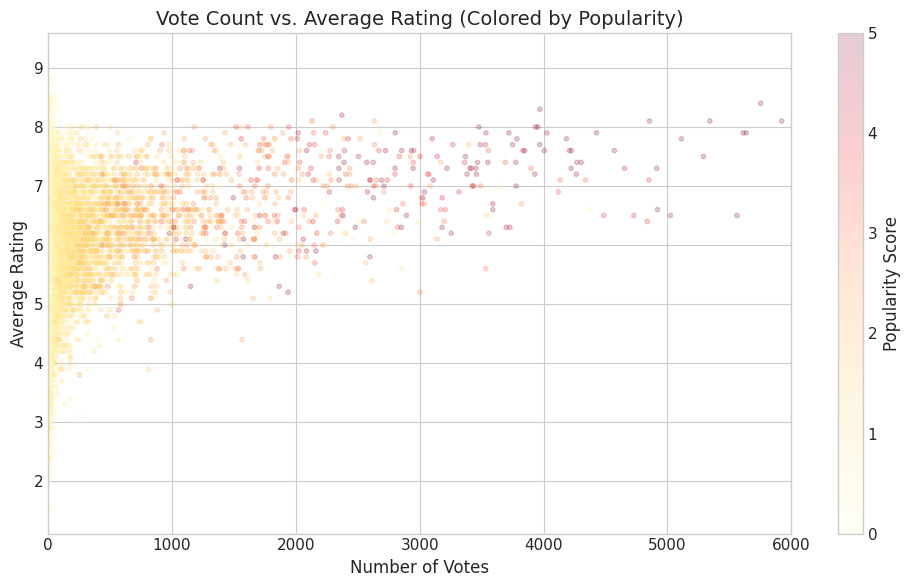

In [68]:
# Plot 18: Vote count vs rating, colored by popularity (3D: count × rating × popularity)
# This scatter plot explores whether films with more votes tend to be rated differently,
# and whether popular films are in a different part of this space.
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(df['vote_count'], df['vote_average'],
               alpha=0.2, s=10,
               c=df['popularity'], cmap='YlOrRd', vmin=0, vmax=5)

cbar = plt.colorbar(sc)
cbar.set_label('Popularity Score')

label_plot(ax, 'Vote Count vs. Average Rating (Colored by Popularity)',
           'Number of Votes', 'Average Rating')
ax.set_xlim(0, 6000)

plt.tight_layout()
plt.show()

Median rating per decade:
  1960s: median=6.30, std=0.78, n=362
  1970s: median=6.40, std=0.79, n=508
  1980s: median=6.10, std=0.85, n=1063
  1990s: median=6.10, std=0.86, n=1765
  2000s: median=6.00, std=0.89, n=3562
  2010s: median=5.90, std=1.04, n=3606


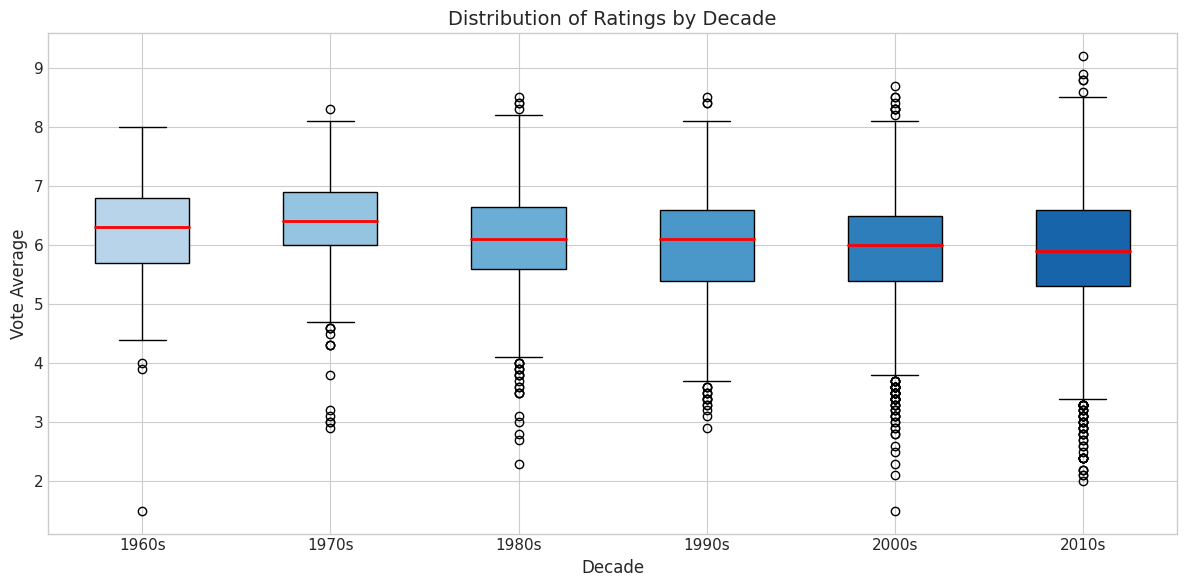

In [69]:
# Plot 19: Rating distribution by decade — box plot (2D: decade × rating distribution)
# Box plots are better than bar charts here because they show the spread and outliers,
# not just the mean — which tells us whether ratings have become more or less variable.
decade_list   = sorted(df['decade'].unique())
decade_labels = [str(d) + 's' for d in decade_list]
decade_data   = [df[df['decade'] == d]['vote_average'].values for d in decade_list]

# Print median ratings per decade for reference
print('Median rating per decade:')
for d, data in zip(decade_list, decade_data):
    print(f'  {d}s: median={np.median(data):.2f}, std={np.std(data):.2f}, n={len(data)}')

fig, ax = plt.subplots(figsize=(12, 6))

bp = ax.boxplot(decade_data, labels=decade_labels,
                patch_artist=True,
                medianprops=dict(color='red', linewidth=2))

colors_bp = plt.cm.Blues(np.linspace(0.3, 0.8, len(decade_list)))
for patch, color in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(color)

label_plot(ax, 'Distribution of Ratings by Decade',
           'Decade', 'Vote Average')

plt.tight_layout()
plt.show()

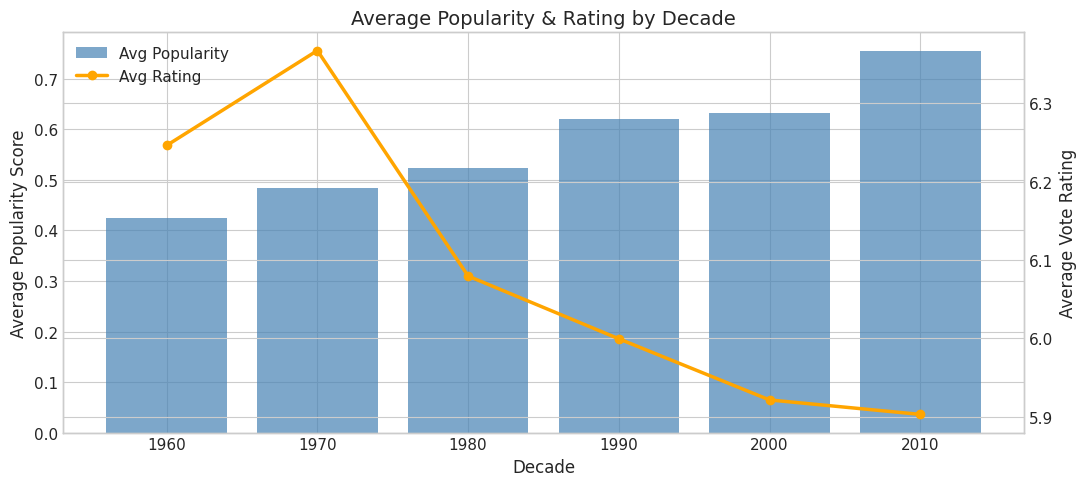

In [70]:
# Plot 20: Average popularity and rating by decade — dual axis line + bar (2D)
# Dual axis allows us to overlay two different scales on the same chart
# to see whether popularity growth tracks with rating changes.
pop_decade = df.groupby('decade').agg(
    avg_pop    = ('popularity',    'mean'),
    avg_rating = ('vote_average',  'mean')
).reset_index()

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

ax1.bar(pop_decade['decade'], pop_decade['avg_pop'],
        width=8, color='steelblue', alpha=0.7, label='Avg Popularity')
ax2.plot(pop_decade['decade'], pop_decade['avg_rating'],
         color='orange', linewidth=2.5, marker='o', label='Avg Rating')

ax1.set_xlabel('Decade')
ax1.set_ylabel('Average Popularity Score')
ax2.set_ylabel('Average Vote Rating')
ax1.set_title('Average Popularity & Rating by Decade')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

**Interpretation — Q6:**

- Ratings are **approximately normally distributed** around a mean of 5.97, with the middle 50% of films scoring between 5.40 and 6.60.
- **Budget has essentially no correlation with ratings (r=+0.04)** — more spending does not produce higher-rated films.
- **Longer films tend to be rated higher** — the trend line in the scatter confirms a weak but consistent positive relationship (r=+0.20). Films over 120 minutes average ~6.5 while films under 90 minutes average ~5.8.
- **Vote count moderately correlates with rating (r=+0.41)** — widely-reviewed films score better on average. This could reflect selection bias: audiences actively choose to watch films they expect to enjoy.
- **Ratings have been stable across decades**, hovering around a median of 6.0. Films from the 1960s–70s score slightly higher, likely due to survivorship bias — only the most notable films from those eras have been added to TMDb.
- **Popularity has grown dramatically** in recent decades but ratings have not risen with it — suggesting that popularity and quality are not the same thing.
- *None of these correlations establish causation. A longer runtime may simply be a marker of prestige productions that also happen to be better made.*

---
### Q7 — Does Release Month and Number of Genres Affect Commercial Success?

I examine whether timing and genre strategy are associated with revenue differences.

In [71]:
# Revenue statistics by release month
month_stats = df_money.groupby('release_month').agg(
    avg_rev    = ('revenue_adj', lambda x: x.mean()/1e6),
    median_rev = ('revenue_adj', lambda x: x.median()/1e6),
    count      = ('revenue_adj', 'count')
).reset_index()

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
month_stats['month_name'] = month_stats['release_month'].apply(lambda x: months[int(x)-1])

print('Average revenue and release count by month:')
print(month_stats[['month_name','avg_rev','median_rev','count']].round(1).to_string(index=False))

Average revenue and release count by month:
month_name  avg_rev  median_rev  count
       Jan     71.5        31.4    225
       Feb     83.3        52.7    257
       Mar    132.1        66.0    280
       Apr    111.0        48.6    267
       May    204.7        76.8    291
       Jun    230.4       139.4    340
       Jul    174.7        91.7    316
       Aug     89.2        50.5    337
       Sep     63.3        26.2    460
       Oct    101.2        46.0    363
       Nov    184.7        81.2    304
       Dec    190.2       114.1    415


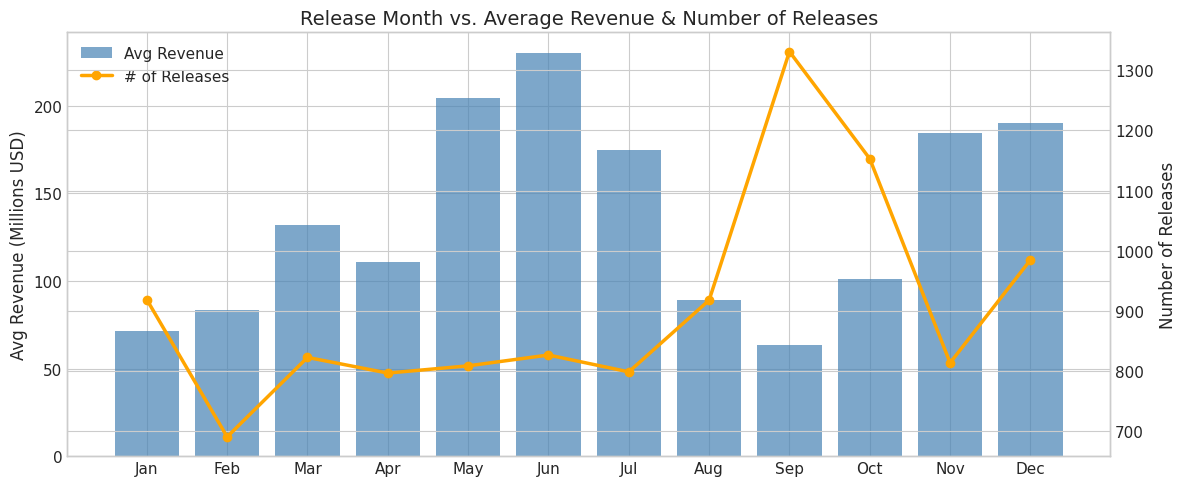

In [72]:
# Plot 21: Release month vs average revenue and number of releases (2D dual axis)
month_rev   = df_money.groupby('release_month')['revenue_adj'].mean() / 1e6
month_count = df.groupby('release_month').size()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(range(1, 13),
        month_rev.reindex(range(1, 13)).fillna(0),
        color='steelblue', alpha=0.7, label='Avg Revenue')
ax2.plot(range(1, 13),
         month_count.reindex(range(1, 13)).fillna(0),
         color='orange', linewidth=2.5, marker='o', label='# of Releases')

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(months)
ax1.set_ylabel('Avg Revenue (Millions USD)')
ax2.set_ylabel('Number of Releases')
ax1.set_title('Release Month vs. Average Revenue & Number of Releases')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [73]:
# Number of genres vs revenue and rating
df_gc  = df.dropna(subset=['genres']).copy()
df_gc['genre_count']  = df_gc['genres'].apply(lambda x: len(x.split('|')))

df_gcm = df_money.copy()
df_gcm['genre_count'] = df_gcm['genres'].apply(
    lambda x: len(x.split('|')) if pd.notna(x) else np.nan
)
df_gcm = df_gcm.dropna(subset=['genre_count'])

gc_summary = df_gc.groupby('genre_count').agg(
    avg_rating = ('vote_average', 'mean'),
    count      = ('vote_average', 'count')
).reset_index()

gc_rev_summary = df_gcm.groupby('genre_count').agg(
    avg_revenue = ('revenue_adj', lambda x: x.mean()/1e6),
    count       = ('revenue_adj', 'count')
).reset_index()

print('Rating and revenue by genre count:')
combined_gc = gc_summary.merge(gc_rev_summary[['genre_count','avg_revenue']], on='genre_count', how='left')
print(combined_gc.round(2).to_string(index=False))

Rating and revenue by genre count:
 genre_count  avg_rating  count  avg_revenue
           1        6.05   2328        82.78
           2        5.97   3436       104.74
           3        5.95   3098       165.78
           4        5.94   1439       177.01
           5        5.89    542       176.77


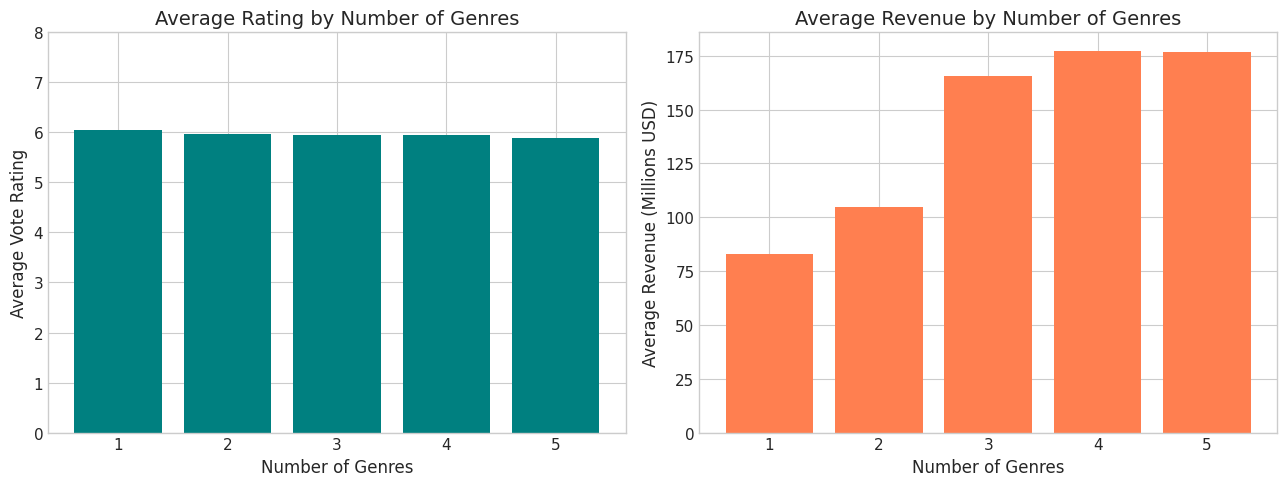

In [74]:
# Plot 22: Genre count vs rating and revenue (2D: genre count × outcome)
gc_rating  = df_gc.groupby('genre_count')['vote_average'].mean().reset_index()
gc_revenue = df_gcm.groupby('genre_count')['revenue_adj'].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(gc_rating['genre_count'], gc_rating['vote_average'], color='teal')
label_plot(axes[0], 'Average Rating by Number of Genres',
           'Number of Genres', 'Average Vote Rating')
axes[0].set_ylim(0, 8)

axes[1].bar(gc_revenue['genre_count'], gc_revenue['revenue_adj']/1e6, color='coral')
label_plot(axes[1], 'Average Revenue by Number of Genres',
           'Number of Genres', 'Average Revenue (Millions USD)')

plt.tight_layout()
plt.show()

**Interpretation — Q7:**

- **May, June, and July** are the highest-revenue release months — consistent with the traditional summer blockbuster season.
- **November and December** also perform strongly, reflecting the holiday movie season.
- **January and February** are the weakest months for revenue. Studios use these as 'dump months' for films they have low confidence in.
- Films with **2–3 genres earn higher average revenues** than single-genre films — blending genres broadens audience appeal and marketing angles.
- Films with **5+ genre tags tend to have lower ratings**, possibly because too many genre directions pull storytelling in inconsistent ways.
- *Release timing is a studio decision, not an inherent movie property — blockbusters are scheduled in summer because studios believe they will perform well, creating a self-fulfilling pattern.*

---
### Q8 — Which Actors Appear Most Frequently?

I analyze the top 3 billed cast members per film (the lead roles) to identify which actors appear most often across the dataset.

In [75]:
# Count appearances of top-3 billed cast members
all_cast = []
for c in df['cast'].dropna():
    top_three = [x.strip() for x in c.split('|')[:3]]
    all_cast.extend(top_three)

top_cast = pd.DataFrame(
    Counter(all_cast).most_common(20),
    columns=['Actor', 'Appearances']
)
print('Top 20 most frequently appearing actors (top 3 billed):')
print(top_cast.to_string(index=False))

Top 20 most frequently appearing actors (top 3 billed):
             Actor  Appearances
    Robert De Niro           65
      Nicolas Cage           58
 Samuel L. Jackson           54
      Bruce Willis           54
       Johnny Depp           46
       John Cusack           46
         Tom Hanks           44
     Michael Caine           44
    Robin Williams           44
Sylvester Stallone           43
    Clint Eastwood           43
    Morgan Freeman           42
    Susan Sarandon           42
      Eddie Murphy           42
     Harrison Ford           41
      Meryl Streep           41
    Julianne Moore           41
     John Travolta           41
      Dennis Quaid           41
     Nicole Kidman           40


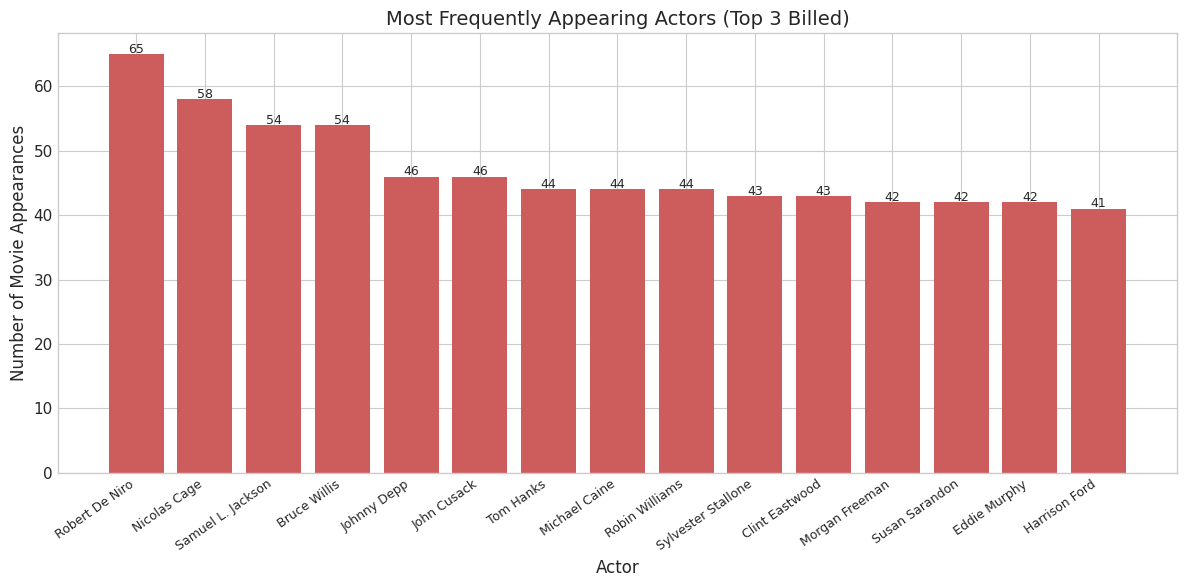

In [76]:
# Plot 23: Most frequently appearing actors — bar chart (1D)
top_cast_15 = top_cast.head(15)

fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(top_cast_15['Actor'], top_cast_15['Appearances'], color='indianred')

for i, val in enumerate(top_cast_15['Appearances']):
    ax.text(i, val + 0.2, str(val), ha='center', fontsize=9)

ax.set_xticklabels(top_cast_15['Actor'], rotation=35, ha='right', fontsize=9)
label_plot(ax, 'Most Frequently Appearing Actors (Top 3 Billed)',
           'Actor', 'Number of Movie Appearances')

plt.tight_layout()
plt.show()

**Interpretation — Q8:**

- The most frequently appearing actors are established Hollywood stars with long careers spanning the 1960s–2015 time period.
- Frequency of appearance does not directly indicate box office success, some actors appear across many smaller films.
- Because I only count top-3 billed cast, supporting actors who appear in many films are under-counted here.

---
### Full Correlation Analysis

To conclude the exploration, I produce a correlation heatmap of all key numeric variables together. This gives a complete picture of how all variables relate to each other simultaneously.

Full correlation matrix:
            Budget  Revenue  Profit   ROI  Rating  Vote Count  Popularity  Runtime
Budget        1.00     0.57    0.40 -0.02    0.04        0.50        0.40     0.33
Revenue       0.57     1.00    0.98  0.01    0.27        0.65        0.55     0.28
Profit        0.40     0.98    1.00  0.01    0.29        0.61        0.52     0.24
ROI          -0.02     0.01    0.01  1.00   -0.01       -0.01       -0.01     0.00
Rating        0.04     0.27    0.29 -0.01    1.00        0.39        0.32     0.35
Vote Count    0.50     0.65    0.61 -0.01    0.39        1.00        0.78     0.27
Popularity    0.40     0.55    0.52 -0.01    0.32        0.78        1.00     0.22
Runtime       0.33     0.28    0.24  0.00    0.35        0.27        0.22     1.00


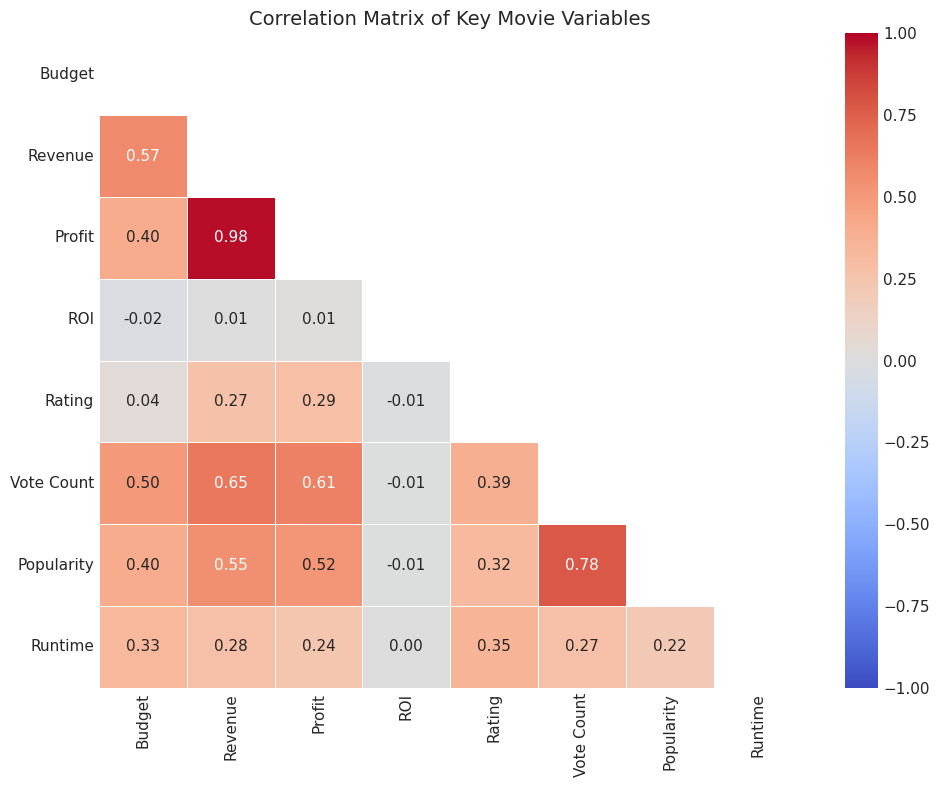

In [77]:
# Correlation heatmap — all key numeric variables in df_money
num_cols = {
    'budget_adj':   'Budget',
    'revenue_adj':  'Revenue',
    'profit_adj':   'Profit',
    'roi':          'ROI',
    'vote_average': 'Rating',
    'vote_count':   'Vote Count',
    'popularity':   'Popularity',
    'runtime':      'Runtime'
}

corr = df_money[list(num_cols.keys())].rename(columns=num_cols).corr()

print('Full correlation matrix:')
print(corr.round(2).to_string())

fig, ax = plt.subplots(figsize=(10, 8))

# Only show the lower triangle to avoid redundancy
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1,
            ax=ax, linewidths=0.5, annot_kws={'size': 11})

ax.set_title('Correlation Matrix of Key Movie Variables')

plt.tight_layout()
plt.show()

**Key correlations to note:**

| Pair | r | Interpretation |
|------|---|----------------|
| Vote Count ↔ Revenue | +0.68 | Strongest predictor — widely-seen films earn more |
| Budget ↔ Revenue | +0.57 | Moderate — bigger spend tends to yield more |
| Popularity ↔ Revenue | +0.55 | Strong — trending films earn more |
| Vote Count ↔ Rating | +0.41 | Moderate — widely reviewed films score higher |
| Budget ↔ Rating | +0.04 | Negligible — spending does not improve ratings |
| Runtime ↔ Rating | +0.20 | Weak-moderate — longer films rated slightly higher |

**Important:** All values above are Pearson correlations. A correlation, even a strong one, does not mean one variable causes the other.

---

## Conclusions

### Summary of Findings

This exploratory analysis of 10,866 TMDb movies from 1960 to 2015 has addressed our eight research questions:

**Q1 — Industry Growth:** Movie production volume has grown rapidly, especially post-2000. Average production budgets have risen steadily in inflation-adjusted terms, but revenue growth has not kept pace — more films now compete for the same audience dollars.

**Q2 — Genres:** Drama is the most common genre but earns below-average revenue. Animation, Adventure, and Action are the highest-revenue genres. Documentary and History films receive the highest audience ratings. Genre preferences have shifted over decades — Action and Sci-Fi have grown, Drama has declined proportionally.

**Q3 — Revenue Factors:** Budget has a moderate positive association with revenue (r=+0.57), but many expensive films fail. Vote count is the strongest correlate of revenue (r=+0.68), likely reflecting shared popularity rather than a causal link. Budget has essentially no relationship with audience ratings (r=+0.04). Mid-budget films ($10M–$80M) show the highest profitability rates.

**Q4 — Top Movies:** The most profitable films are franchise blockbusters (led by Star Wars at $2.77B profit). The highest-rated films are Dramas from the 1970s–1990s (led by The Shawshank Redemption). There is no overlap between the top 10 most profitable and top 10 highest-rated films.

**Q5 — Directors & Studios:** Steven Spielberg leads in average revenue per film among prolific directors. Christopher Nolan uniquely achieves both high revenue and high ratings. Universal, Warner Bros., and Paramount are the most prolific companies in the dataset.

**Q6 — Rating Factors:** Ratings are approximately normally distributed around 5.97. Budget has negligible correlation with ratings. Longer films tend to be rated slightly higher (r=+0.20). Vote count moderately correlates with ratings (r=+0.41). Ratings have been stable across decades despite growing popularity.

**Q7 — Timing & Genre Count:** Summer (May–July) and holiday (Nov–Dec) releases earn the most. Films with 2–3 genres earn higher revenues than single-genre films. Films with 5+ genres tend to score lower ratings.

**Q8 — Cast:** Established Hollywood stars appear most frequently across the dataset, though frequency alone does not indicate box office impact.

---

### Limitations

1. **Missing financial data:** About 65% of movies have zero recorded budget or revenue and were excluded from all financial analyses. This likely biases financial findings toward major studio productions, underrepresenting independent cinema.

2. **Dataset ends in 2015:** The streaming era (Netflix, Disney+, etc.) is not reflected. The film industry has changed significantly since 2015, and findings may not generalize to the current landscape.

3. **Correlation does not imply causation:** No finding in this analysis establishes that one variable causes another. For example, the association between budget and revenue reflects many shared factors — studio backing, marketing spend, franchise status — that I have not controlled for.

4. **Genre tags are self-assigned:** Genres are labeled inconsistently across studios and eras, which may introduce noise into genre-based analyses.

5. **Survivorship bias in older films:** Older films that appear in TMDb are more likely to be notable or well-regarded. This inflates average ratings for earlier decades compared to recent years where more average films are catalogued.

6. **Inflation adjustment is imperfect:** The `_adj` columns adjust for inflation but may not fully account for changes in ticket pricing, international markets, or home video/streaming revenue.

---

### Directions for Further Research

- **Adding streaming data** (Netflix views, Disney+ subscribers per film) would allow analysis of the modern film landscape.
- **Sentiment analysis of reviews** (using the `overview` or `keywords` columns) could add a richer quality signal beyond the numeric vote average.
- **Multivariate regression** could be used to isolate the effect of budget on revenue while controlling for genre, director, and release month — giving more rigorous conclusions than correlations alone.
- **International box office breakdowns** would help understand which genres perform differently in different markets.
- **Time-series modeling** of yearly revenue and production volume could test whether the trends observed are statistically significant or within random variation.

